#### BiG NOTE ABOUT PROJECT
I was unable to get past the rate limit error - 529 during the final execution of notebook.  I left those errors in the notebook output.
The code is mostly complete but there are a few optimizations I could still make.  Those are found in the technical recommendations pdf in the conclusions section of the notebook.  The file is named rag_evaluation_insights.pdf.


## Problem Statement

### Business Context

GlobalEdge Brokerage is a mid-sized brokerage firm operating across multiple countries, serving thousands of retail and institutional clients through a network of equity brokers. Brokers handle investment recommendations, portfolio reviews, and market advisory discussions across equity, forex, commodity, crypto, and international stock markets. Each broker manages hundreds of clients and is expected to stay updated with overnight market developments before the market opens.

Every morning, brokers must review large volumes of financial news, stock-price movements, earnings discussions, analyst commentary, and SEC regulatory filings within a very limited preparation window. In practice, brokers can only read a small portion of the available information before their first client calls begin. As a result, many important signals, disclosures, and market events remain unnoticed.

This creates an intelligence gap during client interactions. Brokers often rely on partial information, memory, or fragmented market sources while answering client questions. Important disclosures buried inside long 10-K and 10-Q filings are difficult to review manually, and brokers may struggle to provide evidence-backed responses when clients ask for justification or supporting references. This increases both compliance risk and trust-related challenges.

To solve this problem, GlobalEdge wants to build a financial intelligence assistant that allows brokers to ask natural-language questions and receive grounded answers backed by real financial data, news articles, and regulatory filings. The system should reduce information overload, improve market coverage, and help brokers make faster and more confident advisory decisions without adding technical complexity to their workflow.

### Objective

This project proposes a proof-of-concept Retrieval-Augmented Generation (RAG) financial intelligence system that combines financial news, stock-price data, and SEC filings into a searchable intelligence layer. The system uses semantic retrieval with a local Chroma vector database to fetch relevant financial context and generate grounded answers for broker questions using large language models. Brokers can ask plain-English questions such as market sentiment analysis, company-risk queries, filing-related questions, or cross-market comparisons and receive evidence-backed responses.

To improve the quality and reliability of generated answers, the system introduces a DeepEval-based prompt optimization workflow using GEPA (Genetic-Pareto Prompt Optimization). Instead of manually refining prompts, the workflow uses benchmark financial question-answer examples and evaluation metrics such as faithfulness, groundedness, relevance, and actionability to optimize the final answering prompt.

The project also evaluates multiple RAG configurations by tuning retrieval and generation parameters such as chunk size, chunk overlap, number of retrieved chunks, temperature, top-p, and maximum token limits. Each configuration is evaluated using DeepEval metrics to identify the most effective combination for grounded financial reasoning and broker-style question answering.

The final system uses the optimized prompt together with the best-performing RAG configuration to generate accurate, grounded, and production-style financial intelligence responses for broker workflows.

### Data Description

The system uses three financial intelligence datasets collected through a custom data ingestion pipeline and stored locally for the RAG workflow.
1. Global Financial News (global_news.csv)
Contains financial news articles with titles, article content, publication dates, URLs, and source metadata. The dataset covers company announcements, market developments, macroeconomic events, sector movements, and sentiment-related signals.
2. Global Stock Prices (all_prices_clean.csv)
Contains historical stock-price data across global equity markets, crypto markets, and forex markets. Each record includes ticker symbols, company names, open/high/low/close prices, trading volume, and timestamps for market analysis and trend evaluation.
3. SEC Regulatory Filings (sec_filings.txt)
Contains regulatory filing documents including 10-K annual reports, 10-Q quarterly reports, and other SEC disclosures. These filings include financial statements, governance information, risk disclosures, operational commentary, and compliance-related information used for grounded financial reasoning.

# Blueprint
1	A reliable financial RAG pipeline — ingestion → normalization → chunking → embedding → Chroma → retrieval → answer generation.

2 An experimental/evaluation pipeline — benchmark questions → DeepEval → configuration experiments → GEPA prompt optimization → final validation.
That separation will make debugging much easier. In particular, you want to know whether a bad answer came from retrieval, generation, or the prompt.


### 1. Define what the POC must demonstrate
Before coding, translate the objective into measurable requirements.
Your POC should demonstrate that a broker can ask questions such as:
* “What risks did Apple identify in its latest 10-K?”
* “Why did NVIDIA's margins change?”
* “What has been the recent sentiment around Tesla?”
* “Compare Microsoft's recent stock performance with Amazon.”
* “What SEC disclosures support the claim that company X faces increasing regulatory risk?”

### And receive something resembling:
Answer
NVIDIA reported that gross margin declined primarily because of...
Supporting evidence
* NVIDIA 10-Q, Item 2 — Management Discussion
* Reuters article, August 18, 2026
*	NVIDIA price data, August 1–20, 2026
# Confidence / evidence status
Supported by SEC filing and recent market data.
The critical requirement is that the LLM shouldn't be answering financial questions merely from its pretrained knowledge. The answer should be derived from the retrieved context.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Installing and Importing Necessary Libraries and Dependencies

In [ ]:
# Installing the necessary libraries with specified versions
%pip install -qU \
    "chromadb==1.5.9" \
    "langchain-community==0.4.1" \
    "langchain-chroma==1.1.0" \
    "langchain-openai==1.2.1" \
    "langchain-text-splitters==1.1.2" \
    "pandas==3.0.3" \
    "numpy==2.4.4" \
    "scikit-learn>=1.4.0" \
    "python-dotenv>=1.0.1" \
    "tqdm>=4.66.0"\
    "deepeval==4.0.2"

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for VSCode), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

*Restart the runtime*

In [ ]:
# Importing the necessary libraries

# Standard Python libraries for file handling, text processing, JSON handling,
# randomness, timing, and basic utilities.
import os
import re
import json
import random
import time
from pathlib import Path
from collections import Counter
import pandas as pd

# DeepEval libraries for prompt optimization and evaluation.
from deepeval.prompt import Prompt
from deepeval.dataset import Golden
from deepeval.metrics import GEval
from deepeval.optimizer import PromptOptimizer
from deepeval.optimizer.algorithms import GEPA
from deepeval.test_case import LLMTestCase, SingleTurnParams
from deepeval.models import GPTModel
from deepeval.optimizer.policies import TieBreaker

# LangChain libraries for document loading, text splitting, embeddings,
# vector storage, and LLM interaction.
from langchain_community.document_loaders import CSVLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

## Environment Setup and Project Initialization

In [ ]:
#Write your code here
DATA_DIR = "/content/drive/MyDrive/UTAIGA/Financial_Dataset"

GLOBAL_NEWS = os.path.join(DATA_DIR, "global_news.csv")
STOCK_PRICES = os.path.join(DATA_DIR, "stock_price_details.csv")
SEC_FILINGS = os.path.join(DATA_DIR, "sec_filings_10k.txt")
GOLDEN_DATA = os.path.join(DATA_DIR, "golden_benchmark_dataset.csv")

In [ ]:
# Load the API credentials from config.json and expose them as environment
# variables that the OpenAI SDK reads automatically.

with open("/content/drive/MyDrive/config.json", "r") as f:
    config = json.load(f)

# The same API key works for both sync and async clients.
os.environ["OPENAI_API_KEY"] = config["OPENAI_API_KEY"]
os.environ["OPENAI_BASE_URL"] = config["OPENAI_BASE_URL"]
#"OPENAI_API_BASE": "https://api.openai.com/v1" If I want to use key from openAI

# Section 1: Baseline Retrieval-Augmented Generation (RAG) Pipeline

## 1.1 Load the CSV files with `CSVLoader`

In [ ]:
# Write your code here
from langchain_community.document_loaders import CSVLoader, DirectoryLoader

# Set up the directory loader to target only .csv files
loader = DirectoryLoader(
    path=DATA_DIR,
    glob="**/*.csv",
    loader_cls=CSVLoader
)

# Load data into a list of Document objects
documents = loader.load()

for doc in documents:
    # Ensure metadata is an active dictionary
    if doc.metadata is None:
        doc.metadata = {}

for doc in documents:
      doc.metadata["source_file"] = DATA_DIR + "/" + doc.metadata["source"]
      doc.metadata["source_type"] = "csv"

print(documents)

for i, doc in enumerate(documents[:3]):
    print(f"--- Document {i+1} ---")
    print("Source File:", doc.metadata.get("source"))
    print("Row Content:\n", doc.page_content)
    print("\n")

## Normalize the data
Standardize the data, remove unneeded columns and stuff.

In [ ]:
# def normalize_pipeline(df_news: pd.DataFrame, df_prices: pd.DataFrame, df_sec: pd.DataFrame) -> pd.DataFrame:
#     """
#     Normalizes schemas, aligns datetimes, and unifies the three sources
#     into a single standardized timeline dataframe.
#     """
#     # --- Standardize News ---
#     df_news_norm = df_news.copy()
#     df_news_norm['date'] = pd.to_datetime(df_news_norm['timestamp']).dt.normalize()
#     df_news_norm['source'] = 'NEWS'
#     # Combine or map payload into a standardized dictionary or column
#     df_news_norm['payload'] = df_news_norm['headline']
#     df_news_norm = df_news_norm[['date', 'ticker', 'source', 'payload']]

#     # --- Standardize Prices ---
#     df_prices_norm = df_prices.copy()
#     df_prices_norm['date'] = pd.to_datetime(df_prices_norm['date']).dt.normalize()
#     df_prices_norm['source'] = 'PRICES'
#     # Store numerical price metrics as strings or structured payloads
#     df_prices_norm['payload'] = df_prices_norm['close'].astype(str)
#     df_prices_norm = df_prices_norm[['date', 'ticker', 'source', 'payload']]

#     # --- Standardize SEC ---
#     df_sec_norm = df_sec.copy()
#     # Handle YYYYMMDD format from file names
#     df_sec_norm['date'] = pd.to_datetime(df_sec_norm['raw_date'], format='%Y%m%d').dt.normalize()
#     df_sec_norm = df_sec_norm[['date', 'ticker', 'source', 'content']]
#     df_sec_norm.rename(columns={'content': 'payload'}, inplace=True)

#     # --- Unify into a single timeline ---
#     # axis=0 stacks them vertically
#     unified_timeline = pd.concat([df_news_norm, df_prices_norm, df_sec_norm], axis=0, ignore_index=True)

#     # Clean up strings and sort chronologically
#     unified_timeline['ticker'] = unified_timeline['ticker'].str.upper().str.strip()
#     unified_timeline.sort_values(by=['date', 'ticker'], inplace=True, ignore_index=True)

#     return unified_timeline

## 1.2 Load the SEC filings text and split it into chunks


In [ ]:
# Write your code here
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

# 1. Load the text file
loader = TextLoader(SEC_FILINGS, encoding="utf-8")
sec_documents = loader.load()

# Add metadata to every filing document so the original source remains traceable later.
for doc in sec_documents:
    doc.metadata["source_file"] = SEC_FILINGS

    doc.metadata["source_type"] = "csv"

# 2. Initialize the text splitter
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=2000,       # Number of chars per chunk
    chunk_overlap=200,     # Number of char overlap between chunks
    length_function=len    # length of chunks
)

# 3. Break the document into chunks
filing_chunks = text_splitter.split_documents(sec_documents)

# Verification
print(f"Loaded {len(documents)} documents.")
print(f"Created {len(filing_chunks)} chunks.")

# Example: Previewing the first chunk
if filing_chunks:
    print("\n--- First Chunk Preview ---")
    print(filing_chunks[1].page_content)
    print("\nMetadata:", filing_chunks[0].metadata)

Loaded 3766 documents.
Created 4498 chunks.

--- First Chunk Preview ---
msft:ServerProductsAndCloudServicesMember 2022-07-01 2023-06-30 0000789019 msft:IssuanceOfLongTermDebtEightMember 2024-06-30 0000789019 msft:IntelligentCloudMember 2022-07-01 2023-06-30 0000789019 msft:ActivisionBlizzardIncMember us-gaap:TechnologyBasedIntangibleAssetsMember 2023-10-13 0000789019 msft:ActivisionBlizzardIncMember 2022-07-01 2023-06-30 0000789019 msft:ShareRepurchaseProgramTwentyNineteenMember 2019-09-18 0000789019 msft:ActivisionBlizzardIncMember us-gaap:MarketingRelatedIntangibleAssetsMember 2023-10-13 2023-10-13 0000789019 msft:IssuanceOfLongTermDebtFiveMember 2023-06-30 0000789019 us-gaap:SoftwareAndSoftwareDevelopmentCostsMember 2024-06-30 0000789019 us-gaap:ProductMember 2023-07-01 2024-06-30 0000789019 msft:SearchAndNewsAdvertisingMember 2023-07-01 2024-06-30 0000789019 msft:IssuanceOfLongTermDebtElevenMember srt:MaximumMember 2024-06-30 0000789019 us-gaap:PerformanceSharesMember 2023-07-01 2

## 1.3 Build a local Chroma vector store

*Check the API_KEY*

In [ ]:
# Write your code here
import os
from dotenv import load_dotenv

load_dotenv() # Try loading it explicitly

base_url_value = os.environ.get("OPENAI_BASE_URL")
api_key_value = os.environ.get("OPENAI_API_KEY")

print(f"DEBUG -> BASE_URL found: {base_url_value is not None} (Value: {base_url_value})")
print(f"DEBUG -> API_KEY found: {api_key_value is not None}")
if api_key_value:
    # Print just the first 5 characters to see if it matches your working key
    print(f"DEBUG -> API_KEY starts with: {api_key_value[:5]}...")

DEBUG -> BASE_URL found: True (Value: https://aibe.mygreatlearning.com/openai/v1)
DEBUG -> API_KEY found: True
DEBUG -> API_KEY starts with: gl-U2...


In [ ]:
os.environ["LANGCHAIN_TRACING_V2"] = "false"
import getpass
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

# Run this before os.environ.get()
load_dotenv()
# Get all the documents
all_documents = documents + filing_chunks

# 1. Reload the local persistent database
persist_directory = "./chroma_db"
embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",
    # api_key = os.environ.get("OPENAI_API_KEY"),
    # base_url = os.environ.get("OPENAI_BASE_URL")
    # api_key = api_key_value,
    # base_url = base_url_value
    api_key = getpass.getpass("OpenAI API Key:"),
    base_url = getpass.getpass("OpenAI Base URL:")
    # api_key = config["OPENAI_API_KEY"],
    # base_url = config["OPENAI_BASE_URL"]
    )

vector_store = Chroma.from_documents(
    documents=all_documents,
    persist_directory=persist_directory,
    embedding=embeddings)

## 1.4 Retrieve Context and Generate Answers using the Baseline RAG Pipeline

In [ ]:
# Initialize the Language Model
llm = ChatOpenAI(model="gpt-4o",
                 temperature=0,
                #  api_key = os.getenv("OPENAI_API_KEY"),
                #  base_url = os.getenv("OPENAI_BASE_URL")
                 api_key = getpass.getpass("OpenAI API Key:"),
                 base_url = getpass.getpass("OpenAI Base URL:")
)

In [ ]:
# Format retrieved documents helper
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

In [ ]:
# Run this before os.environ.get()
load_dotenv()
# Convert the vector store into a retriever and get the 3 top chunks
retriever = vector_store.as_retriever(search_kwargs={"k":3})

# Define the RAG prompt template
template = """You are a helpful assistant. Use the following pieces of retrieved context to answer the question.
If you don't know the answer, say that you don't know. Keep the answer concise.

Context:
{context}

Question: {question}
Answer:"""

prompt = ChatPromptTemplate.from_template(template)

# Construct the RAG Chain
rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

# Execute a query
query = "What are the key instructions found in the text file?"
response = rag_chain.invoke(query)

print(f"Query: {query}\n")
print(f"Response:\n{response}")

Query: What are the key instructions found in the text file?

Response:
The text file appears to be an index or table of contents for a document, likely a financial report or regulatory filing. It lists various sections and items, such as "Properties," "Legal Proceedings," "Mine Safety Disclosures," "Market for Registrant’s Common Equity," "Management’s Discussion and Analysis of Financial Condition and Results of Operations," "Financial Statements and Supplementary Data," and others. Each item is associated with a page number. There are no specific instructions found in the text file.


In [ ]:
def retrieve_chunks(question: str, k=3):
    return vector_store.similarity_search(question, k=k)

In [ ]:
# The baseline prompts
BASELINE_SYSTEM_PROMPT = """

You are a financial intelligence assistant for brokers. Your job is to answer the user's question accurately using only the provided pieces of
retrieved financial context, which includes SEC filings, financial news, and stock data.

If the retrieved context does not contain enough information to answer the question, state clearly that you do not have enough information.
Do not make up facts, figures, or historical data.


"""

BASELINE_USER_PROMPT = """

Review the following pieces of retrieved financial context, then answer the broker's question.
Ensure your answer is directly supported by the text below.

Broker Question:
{question}

Retrieved Context:
{context}

""".strip()


In [ ]:
def baseline_answer(question: str, k=3) -> dict:
    """
    Generate an answer using the baseline RAG workflow.

    Steps:
    1. Retrieve relevant financial context
    2. Build the grounded prompt
    3. Send the prompt to the LLM
    4. Return the generated answer and retrieved sources
    """

    # Retrieve relevant chunks from Chroma
    docs = retrieve_chunks(question, k=k)

    # Convert retrieved documents into prompt-ready context
    context = format_docs(docs)

    # Inject the runtime values into the prompt template
    user_prompt = BASELINE_USER_PROMPT.format(
        question=question,
        context=context,
    )

    # Generate the final response
    response = llm.invoke([
        SystemMessage(content=BASELINE_SYSTEM_PROMPT),
        HumanMessage(content=user_prompt),
    ])

    return {
        "answer": response.content,
        "docs": docs,
        "context": context,
    }

*Accidently erased the output from these two tests and couldn't run them again due to 529s.  They worked fine.*

In [ ]:
baseline_answer("Summarize any overnight regulatory disclosures or unexpected management updates from our covered international equity listings.")

In [ ]:
baseline_answer("What are the key instructions found in the text file")

## 1.5 Load the gold benchmark dataset and evaluate the baseline prompt


In [ ]:
def load_gold_benchmark(file_path: str) -> list[dict[str, any]]:
  golden_df = pd.read_csv(GOLDEN_DATA)

  required_cols = ["question", "response", "context"]
  missing_cols = [col for col in required_cols if col not in golden_df.columns]
  if missing_cols:
      raise ValueError(
          f"Missing required benchmark columns: {missing_cols}. "
          f"Available columns: {list(df.columns)}"
      )

  rows = []
  for _, row in golden_df.iterrows():
      rows.append({
          "question": str(row["question"]).strip(),
          "response": str(row["response"]).strip(),
          "context": str(row["context"]).strip(),
          "source_hint": str(row["source_hint"]).strip()
          if "source_hint" in golden_df.columns and pd.notna(row.get("source_hint")) else "",
          "supporting_sources": str(row["supporting_sources"]).strip()
          if "supporting_sources" in golden_df.columns and pd.notna(row.get("supporting_sources")) else "",
          "category": str(row["category"]).strip()
          if "category" in golden_df.columns and pd.notna(row.get("category")) else "",
      })
  return rows



In [ ]:
from sklearn.model_selection import train_test_split

# Load the 20 benchmark examples.
gold_rows = load_gold_benchmark(GOLDEN_DATA)

print(f"Golden set size: {len(gold_rows)}")

if len(gold_rows) != 20:
    raise ValueError(f"Only {len(gold_rows)}, there shoud be 20.")

# Build DeepEval Golden objects.
goldens = []
for row in gold_rows:
    goldens.append(
        Golden(
            input=row["question"],
            expected_output=row["response"],
            retrieval_context=[row["context"]]
        )
    )

# Split the gold set into train and test
train_goldens, test_goldens = train_test_split(goldens, test_size=0.2, random_state=42)

print(f"Train set size: {len(train_goldens)}")
print(f"Test set size: {len(test_goldens)}")


Golden set size: 20
Train set size: 16
Test set size: 4


## 1.6 Define the evaluation metrics

In [ ]:
# Define the evaluation metrics.

RELEVANCE_CRITERIA = """
Evaluate how relevant the response is to the user's question.

The response should directly address the question being asked, stay focused
on the requested information, and avoid unrelated or unnecessary information.

Score from 1 to 5:
1 = Completely irrelevant.
2 = Mostly irrelevant.
3 = Partially relevant.
4 = Highly relevant.
5 = Fully relevant and directly answers the question.
"""


COMPLETENESS_CRITERIA = """
Evaluate how completely the response answers the user's question based on
the information available in the provided context.

The response should include all important facts from the context necessary
to fully answer the question.

Score from 1 to 5:
1 = Almost entirely incomplete.
2 = Missing most important information.
3 = Covers some important information but has significant omissions.
4 = Covers nearly all important information.
5 = Fully answers the question using all relevant information from the context.
"""

FAITHFULNESS_CRITERIA = """
Evaluate whether the response is supported by the provided context.

Every factual claim should be directly stated in the context or reasonably
inferred from it. Do not allow fabricated facts, unsupported assumptions,
or contradictions.

Score from 1 to 5:
1 = Mostly unsupported or contradictory.
2 = Contains major unsupported claims.
3 = Mix of supported and unsupported claims.
4 = Almost entirely supported with minor issues.
5 = Fully supported by the provided context.
"""

CORRECTNESS_CRITERIA = """
Evaluate whether the generated answer correctly answers the question when
compared with the reference answer.

The generated answer does not need to use the same wording as the reference
answer, but it should communicate the same essential facts and conclusions.

Score from 1 to 5:
1 = Incorrect.
2 = Mostly incorrect.
3 = Partially correct.
4 = Mostly correct.
5 = Fully correct.
"""

RETRIEVAL_CRITERIA = """
Evaluate the quality of the retrieved context for answering the user's question.

Compare the RETRIEVED CONTEXT with the REFERENCE CONTEXT.

The retrieved context should contain the important information from the
reference context that is necessary to answer the question correctly.

Do not require identical wording. Semantically equivalent information should
be considered a match.

Do not penalize the retrieved context for containing additional information
unless that information is irrelevant enough to interfere with answering
the question.

Score:
1 = The retrieved context contains little or none of the information needed
    to answer the question.
2 = The retrieved context contains some relevant information but misses most
    of the important information.
3 = The retrieved context contains a meaningful portion of the required
    information but has significant omissions.
4 = The retrieved context contains nearly all important information needed
    to answer the question.
5 = The retrieved context contains all important information needed to answer
    the question correctly.
"""

In [ ]:
# This code formats the output from the LLM
from pydantic import BaseModel, Field

class EvaluationResult(BaseModel):
    score: int = Field(
        description="Evaluation score from 1 to 5",
        ge=1, # Greater than or equal to 1
        le=5 # Less than or equal to 5
    )

    reason: str = Field(
        description="Brief explanation for the score"
    )

###Evaluate the quality of the metrics.

In [ ]:
def evaluate_faithfulness(context, answer, llm):
    # context vs answer
    """
    Evaluate whether a RAG-generated answer completely answers the
    question using the relevant information available in the
    retrieved context.

    Parameters
    ----------
    question : str
        The user's question.

    context : str
        The context returned by the RAG retriever.

    answer : str
        The answer generated by the RAG system.

    llm
        The LLM used as the evaluator/judge.

    Returns
    -------
    str
        The evaluator's score and explanation.
    """

    evaluator_llm = llm.with_structured_output(EvaluationResult)
    prompt = f"""
    You are evaluating the completeness of a RAG-generated answer.

    RETRIEVED CONTEXT:
    {context}

    GENERATED ANSWER:
    {answer}

    EVALUATION CRITERIA:
    {FAITHFULNESS_CRITERIA}

        Evaluate whether the generated answer includes all important information
    from the retrieved context that is necessary to answer the question.

    Only consider information relevant to the question. Do not penalize the
    answer for excluding unrelated information from the retrieved context.

    Return your evaluation using exactly this format:

    Score: <1-5>
    Reason: <brief explanation>
    """
    result = evaluator_llm.invoke(prompt)

    return result


def evaluate_correctness(question, reference_answer, answer, llm):
    # golden answer vs generated answer
    """
    Evaluate the correctness of a RAG-generated answer against
    a golden/reference answer.

    Parameters
    ----------
    question : str
        The question being evaluated.

    golden_answer : str
        The expected/reference answer from the golden dataset.

    answer : str
        The answer generated by the RAG system.

    llm
        The LLM being used as the evaluator/judge.

    Returns
    -------
    str
        The evaluator's score and explanation.
    """
    evaluator_llm = llm.with_structured_output(EvaluationResult)
    prompt = f"""
    You are evaluating the correctness of a RAG-generated answer.

    QUESTION:
    {question}

    REFERENCE ANSWER:
    {golden_answer}

    GENERATED ANSWER:
    {answer}

    EVALUATION CRITERIA:
    {CORRECTNESS_CRITERIA}

    Compare the generated answer with the reference answer.

    Evaluate whether the generated answer communicates the same essential
    facts and conclusions needed to correctly answer the question.

    Do not require identical wording.

    Return your evaluation using exactly this format:

    Score: <1-5>
    Reason: <brief explanation>
    """

    result = evaluator_llm.invoke(prompt)

    return result


def evaluate_relevance(question, answer, llm):
    # question vs generated answer
    """
    Evaluate whether a RAG-generated answer completely answers the
    question using the relevant information available in the
    retrieved context.

    Parameters
    ----------
    question : str
        The user's question.

    context : str
        The context returned by the RAG retriever.

    answer : str
        The answer generated by the RAG system.

    llm
        The LLM used as the evaluator/judge.

    Returns
    -------
    str
        The evaluator's score and explanation.
    """

    evaluator_llm = llm.with_structured_output(EvaluationResult)
    prompt = f"""
    You are evaluating the completeness of a RAG-generated answer.

    QUESTION:
    {question}

    GENERATED ANSWER:
    {answer}

    EVALUATION CRITERIA:
    {RELEVANCE_CRITERIA}

        Evaluate whether the generated answer includes all important information
    from the retrieved context that is necessary to answer the question.

    Only consider information relevant to the question. Do not penalize the
    answer for excluding unrelated information from the retrieved context.

    Return your evaluation using exactly this format:

    Score: <1-5>
    Reason: <brief explanation>
    """
    result = evaluator_llm.invoke(prompt)

    return result

def evaluate_completeness(question, context, answer, llm):
    """
    Evaluate whether a RAG-generated answer completely answers the
    question using the relevant information available in the
    retrieved context.

    Parameters
    ----------
    question : str
        The user's question.

    context : str
        The context returned by the RAG retriever.

    answer : str
        The answer generated by the RAG system.

    llm
        The LLM used as the evaluator/judge.

    Returns
    -------
    str
        The evaluator's score and explanation.
    """
    evaluator_llm = llm.with_structured_output(EvaluationResult)
    prompt = f"""
    You are evaluating the completeness of a RAG-generated answer.

    QUESTION:
    {question}

    RETRIEVED CONTEXT:
    {context}

    GENERATED ANSWER:
    {answer}

    EVALUATION CRITERIA:
    {COMPLETENESS_CRITERIA}

    Evaluate whether the generated answer includes all important information
    from the retrieved context that is necessary to answer the question.

    Only consider information relevant to the question. Do not penalize the
    answer for excluding unrelated information from the retrieved context.

    Return your evaluation using exactly this format:

    Score: <1-5>
    Reason: <brief explanation>
    """

    result = evaluator_llm.invoke(prompt)

    return result

def  evaluate_retrieval_quality(
    question,
    reference_context,
    retrieved_context,
    llm
):

    evaluator_llm = llm.with_structured_output(EvaluationResult)

    evaluation_prompt = f"""
You are evaluating the retrieval quality of a RAG system.

QUESTION:
{question}

REFERENCE CONTEXT:
{reference_context}

RETRIEVED CONTEXT:
{retrieved_context}

EVALUATION CRITERIA:
{RETRIEVAL_CRITERIA}

Determine whether the retrieved context contains the information from the
reference context that is necessary to answer the question.

Do not require identical wording. Evaluate semantic meaning and whether the
necessary evidence was successfully retrieved.
"""

    result = evaluator_llm.invoke(evaluation_prompt)

    return result




In [ ]:
user_question = "Why did margins compress according to the filings?"

retrieved_context = """
1. SEC 10-K FY2025: Net income is down 12% due to rising labor expenditures.
2. SEC filing: Operating margins declined due to higher labor costs.
3. News Wire: Supply chain issues compressed operational margins by 4%.
"""

golden_answer = """
Operating margins declined because of increased labor costs,
higher transportation expenses, and supply chain disruptions.
"""

answer = """
Operating margins declined because of higher labor costs
and supply chain disruptions.
"""

response = """
Margins compressed because of higher labor costs and supply chain issues.
"""

In [ ]:
retrieval = evaluate_retrieval_quality(
    question=user_question,
    reference_context=retrieved_context,
    retrieved_context=answer,
    llm=llm
)

relevance = evaluate_relevance(
    question=user_question,
    answer=answer,
    llm=llm
)

completeness = evaluate_completeness(
    question=user_question,
    context=retrieved_context,
    answer=answer,
    llm=llm
)

faithfulness = evaluate_faithfulness(
    context=retrieved_context,
    answer=answer,
    llm=llm
)

correctness = evaluate_correctness(
    question=user_question,
    reference_answer=golden_answer,
    answer=answer,
    llm=llm
)

In [ ]:
print("--- RETRIEVAL ---")
print(retrieval)

print("\n--- RELEVANCE ---")
print(relevance)

print("\n--- COMPLETENESS ---")
print(completeness)

print("\n--- FAITHFULNESS ---")
print(faithfulness)

print("\n--- CORRECTNESS ---")
print(correctness)

--- RETRIEVAL ---
score=4 reason='The retrieved context accurately captures the two main reasons for margin compression as outlined in the reference context: higher labor costs and supply chain disruptions. However, it does not explicitly mention the specific impact on net income or the exact percentage of margin compression due to supply chain issues, which are minor omissions. Overall, the retrieved context provides nearly all the important information needed to answer the question.'

--- RELEVANCE ---
score=3 reason='The generated answer partially addresses the question by mentioning higher labor costs and supply chain disruptions as reasons for margin compression. However, it lacks specificity and may omit other relevant factors mentioned in the filings, such as changes in raw material costs, pricing strategies, or market conditions. A more comprehensive answer would include all significant reasons cited in the filings.'

--- COMPLETENESS ---
score=4 reason='The generated answer ca

## 1.7 Evaluate the baseline RAG on the golden examples dataset

## Evaluate one example

In [ ]:
def evaluate_example(question, reference_answer, reference_context, retriever, rag_chain, llm):

    # ------------------------------------
    # Retrieve documents
    # ------------------------------------

    retrieved_docs = retriever.invoke(question)

    retrieved_context = "\n\n".join(
        doc.page_content for doc in retrieved_docs
    )

    answer = rag_chain.invoke(question)

    # ------------------------------------
    # Evaluate answer
    # ------------------------------------

    relevance = evaluate_relevance(
        question=question,
        answer=answer,
        llm=llm
    )

    completeness = evaluate_completeness(
        question=question,
        context=retrieved_context,
        answer=answer,
        llm=llm
    )

    faithfulness = evaluate_faithfulness(
        context=retrieved_context,
        answer=answer,
        llm=llm
    )

    correctness = evaluate_correctness(
        question=question,
        reference_answer=reference_answer,
        answer=answer,
        llm=llm
    )

    retrieval_quality = evaluate_retrieval_quality(
        question=question,
        reference_context=reference_context,
        retrieved_context=retrieved_context,
        llm=llm
    )

    # ------------------------------------
    # Return flattened results
    # ------------------------------------


    return {
    "question": question,
    "reference_answer": reference_answer,
    "reference_context": reference_context,
    "generated_answer": answer,
    "retrieved_context": retrieved_context,
    "retrieval_score": retrieval_quality.score,
    "retrieval_reason": retrieval_quality.reason,

    "relevance_score": relevance.score,
    "relevance_reason": relevance.reason,

    "completeness_score": completeness.score,
    "completeness_reason": completeness.reason,

    "faithfulness_score": faithfulness.score,
    "faithfulness_reason": faithfulness.reason,

    "correctness_score": correctness.score,
    "correctness_reason": correctness.reason
    }

In [ ]:
golden_df = pd.read_csv(GOLDEN_DATA)

print(golden_df.columns)
golden_df.head()

Index(['question', 'response', 'source_hint', 'supporting_sources', 'context'], dtype='str')


,question,response,source_hint,supporting_sources,context
0,Given the internal control audit for the fisca...,No material weaknesses were identified. Ernst ...,Apple,sec_filings.txt,"[Source 1] reporting as of September&#160;27, ..."
1,There is market chatter about executive transi...,The Principal Executive Officer is Timothy D. ...,Apple,sec_filings.txt,[Source 1] and in the capacities and on the da...
2,Does Apple’s 10-K disclose any recent changes ...,No. Item 9A of the filing states there were no...,Apple,sec_filings.txt,[Source 1] changes in the Company&#8217;s inte...
3,A client is skeptical of automated financial r...,Apple states that internal controls are design...,Apple,sec_filings.txt,[Source 1] statements in accordance with gener...
4,"Based on the 2025 Form 10-K, what was the as-o...",Apple assessed internal control over financial...,Apple,sec_filings.txt,"[Source 1] reporting as of September&#160;27, ..."


*Check api-key again since the api-key seems to get lost around this point.*

In [ ]:
api_key = os.getenv("OPENAI_API_KEY")

print("API key exists:", api_key is not None)
print("API key length:", len(api_key) if api_key else 0)

API key exists: True
API key length: 64


## Evaluate the entire golden dataset

In [ ]:
results = []

for index, row in golden_df.iterrows():

    print(f"Evaluating {index + 1}/{len(golden_df)}")
    try:
      result = evaluate_example(
          question=row["question"],
          reference_answer=row["response"],
          reference_context=row["context"],
          retriever=retriever,
          rag_chain=rag_chain,
          llm=llm
      )

      results.append(result)

    except Exception as e:
      print(
          f"ERROR evaluating row {index + 1}: "
          f"{type(e).__name__}: {e}"
      )

      results.append({
          "question": row["question"],
          "reference_answer": row["response"],
          "error": str(e)
      })

Evaluating 1/20
Evaluating 2/20
Evaluating 3/20
Evaluating 4/20
Evaluating 5/20
Evaluating 6/20
Evaluating 7/20
Evaluating 8/20
Evaluating 9/20
Evaluating 10/20
Evaluating 11/20
Evaluating 12/20
Evaluating 13/20
Evaluating 14/20
Evaluating 15/20
Evaluating 16/20
Evaluating 17/20
Evaluating 18/20
Evaluating 19/20
Evaluating 20/20


In [ ]:
evaluation_df = pd.DataFrame(results)

evaluation_df.head()

,question,reference_answer,reference_context,generated_answer,retrieved_context,retrieval_score,retrieval_reason,relevance_score,relevance_reason,completeness_score,completeness_reason,faithfulness_score,faithfulness_reason,correctness_score,correctness_reason
0,Given the internal control audit for the fisca...,No material weaknesses were identified. Ernst ...,"[Source 1] reporting as of September&#160;27, ...",No material weaknesses were identified. Ernst ...,question: Given the internal control audit for...,5,The retrieved context contains all the necessa...,5,The generated answer directly addresses the us...,5,The generated answer fully addresses the user'...,5,The generated answer is fully supported by the...,1,The generated answer addresses the question ab...
1,There is market chatter about executive transi...,The Principal Executive Officer is Timothy D. ...,[Source 1] and in the capacities and on the da...,The Principal Officers responsible for Apple's...,question: There is market chatter about execut...,5,The retrieved context accurately identifies th...,5,The generated answer directly addresses the us...,5,The generated answer fully addresses the user'...,5,The generated answer accurately identifies the...,1,The generated answer provides information abou...
2,Does Apple’s 10-K disclose any recent changes ...,No. Item 9A of the filing states there were no...,[Source 1] changes in the Company&#8217;s inte...,"No, Apple's 10-K filing states there were no c...",question: Does Apple’s 10-K disclose any recen...,4,The retrieved context contains nearly all the ...,5,The generated answer is fully relevant and dir...,5,The generated answer fully addresses the user'...,5,The generated answer is fully supported by the...,1,The generated answer addresses the question ab...
3,A client is skeptical of automated financial r...,Apple states that internal controls are design...,[Source 1] statements in accordance with gener...,Apple defines Internal Control Over Financial ...,question: A client is skeptical of automated f...,5,The retrieved context accurately captures the ...,5,The generated answer is fully relevant and dir...,5,The generated answer fully captures the key el...,5,The generated answer is fully supported by the...,1,The generated answer correctly defines Apple's...
4,"Based on the 2025 Form 10-K, what was the as-o...",Apple assessed internal control over financial...,"[Source 1] reporting as of September&#160;27, ...",Apple assessed internal control over financial...,"question: Based on the 2025 Form 10-K, what wa...",5,The retrieved context contains all the necessa...,5,The generated answer is fully relevant and dir...,5,The generated answer fully addresses the user'...,5,The generated answer is fully supported by the...,1,The generated answer provides information abou...


##Calculate base scores

In [ ]:
print(evaluation_df.columns.tolist())

['question', 'reference_answer', 'reference_context', 'generated_answer', 'retrieved_context', 'retrieval_score', 'retrieval_reason', 'relevance_score', 'relevance_reason', 'completeness_score', 'completeness_reason', 'faithfulness_score', 'faithfulness_reason', 'correctness_score', 'correctness_reason']


In [ ]:
score_columns = [
    "relevance_score",
    "completeness_score",
    "faithfulness_score",
    "correctness_score",
    "retrieval_score",
]

baseline_scores = evaluation_df[score_columns].mean()

print(baseline_scores)

relevance_score       4.60
completeness_score    4.30
faithfulness_score    4.10
correctness_score     1.05
retrieval_score       4.05
dtype: float64


*Correctness value is awful, find out which questions choked.*

##Find the ones with the lowest base scores

In [ ]:
evaluation_df.sort_values(
    "correctness_score"
)[
    [
        "question",
        "generated_answer",
        "correctness_score",
        "correctness_reason"
    ]
].head(10)

,question,generated_answer,correctness_score,correctness_reason
0,Given the internal control audit for the fisca...,No material weaknesses were identified. Ernst ...,1,The generated answer addresses the question ab...
1,There is market chatter about executive transi...,The Principal Executive Officer is Timothy D. ...,1,The generated answer provides information abou...
2,Does Apple’s 10-K disclose any recent changes ...,No. Item 9A of the filing states there were no...,1,The generated answer and the reference answer ...
3,A client is skeptical of automated financial r...,Apple defines Internal Control Over Financial ...,1,The generated answer correctly defines Apple's...
4,"Based on the 2025 Form 10-K, what was the as-o...",Apple assessed internal control over financial...,1,The generated answer provides information abou...
5,Does the independent auditor’s report from EY ...,The EY audit covers Apple’s consolidated balan...,1,The generated answer correctly identifies that...
6,SRx Health Solutions recently announced a pivo...,SRx Health Solutions invested more than 10 per...,1,The generated answer does not align with the r...
7,"For brokers monitoring small-cap AI plays, wha...",I don't know.,1,The generated answer 'I don't know' does not p...
8,A naval blockade in the Strait of Hormuz was i...,Oil prices remained relatively stable below 10...,1,The generated answer discusses oil prices and ...
9,With Middle Eastern supply disrupted during Ap...,"Asian refiners, especially in Japan and South ...",1,The generated answer provides information abou...


In [ ]:
evaluation_df.sort_values(
    "relevance_score"
)[
    [
        "question",
        "generated_answer",
        "relevance_score",
        "relevance_reason"
    ]
].head(10)

,question,generated_answer,relevance_score,relevance_reason
7,"For brokers monitoring small-cap AI plays, wha...",I don't know.,1,The generated answer 'I don't know' does not p...
11,Analyze the USDJPY exchange rate during the we...,The Yen weakened against the Dollar during the...,4,The generated answer is highly relevant as it ...
10,Nightview Capital recently discussed Tesla as ...,Nightview Capital described Tesla as a long-te...,4,The generated answer is highly relevant as it ...
15,"How does the April 17, 2026 market intelligenc...",The reports explain that the naval blockade di...,4,The generated answer is highly relevant as it ...
12,"Compare Tencent’s closing price on October 23,...",Tencent’s closing price increased from 633.0 t...,4,The generated answer is highly relevant as it ...
8,A naval blockade in the Strait of Hormuz was i...,Oil prices remained relatively stable below 10...,4,The generated answer is highly relevant as it ...
17,A client asks whether oil prices staying below...,The available intelligence suggests the risk i...,4,The response is highly relevant as it directly...
16,Based on both the SEC filings and recent marke...,Apple appears lower risk because its audited 1...,4,The generated answer is highly relevant as it ...
18,How can a broker demonstrate that Apple manage...,Apple’s 10-K states that management does not e...,4,The generated answer is highly relevant as it ...
6,SRx Health Solutions recently announced a pivo...,SRx Health Solutions invested more than 10 per...,5,The generated answer directly addresses both p...


In [ ]:
evaluation_df.sort_values(
    "faithfulness_score"
)[
    [
        "question",
        "generated_answer",
        "faithfulness_score",
        "faithfulness_reason"
    ]
].head(10)

,question,generated_answer,faithfulness_score,faithfulness_reason
7,"For brokers monitoring small-cap AI plays, wha...",I don't know.,1,The generated answer 'I don't know.' does not ...
14,What was the highest USDJPY price reached duri...,The highest USDJPY price reached during April ...,1,The generated answer claims the highest USDJPY...
13,Was there a significant sell-off day for Tence...,"Yes. On October 31, 2025, Tencent reached a da...",1,The generated answer claims a significant sell...
19,What was Tencent’s trading volume on October 3...,Tencent traded approximately 20.58 million sha...,1,The generated answer states that Tencent trade...
12,"Compare Tencent’s closing price on October 23,...",Tencent’s closing price increased from 633.0 t...,3,The generated answer correctly states the chan...
10,Nightview Capital recently discussed Tesla as ...,Nightview Capital described Tesla as a long-te...,3,The generated answer captures the essence of N...
15,"How does the April 17, 2026 market intelligenc...",The reports explain that the naval blockade di...,4,The generated answer is mostly supported by th...
2,Does Apple’s 10-K disclose any recent changes ...,No. Item 9A of the filing states there were no...,4,The generated answer is mostly supported by th...
16,Based on both the SEC filings and recent marke...,Apple appears lower risk because its audited 1...,4,The generated answer is mostly supported by th...
17,A client asks whether oil prices staying below...,The available intelligence suggests the risk i...,4,The generated answer is almost entirely suppor...


In [ ]:
evaluation_df.sort_values(
    "completeness_score"
)[
    [
        "question",
        "generated_answer",
        "completeness_score",
        "completeness_reason"
    ]
].head(10)

,question,generated_answer,completeness_score,completeness_reason
7,"For brokers monitoring small-cap AI plays, wha...",I don't know.,1,The generated answer 'I don't know' does not p...
10,Nightview Capital recently discussed Tesla as ...,Nightview Capital described Tesla as a long-te...,3,The generated answer captures the core reasoni...
14,What was the highest USDJPY price reached duri...,The highest USDJPY price reached during April ...,3,The generated answer provides the highest USDJ...
15,"How does the April 17, 2026 market intelligenc...",The reports explain that the naval blockade di...,4,The generated answer effectively connects the ...
8,A naval blockade in the Strait of Hormuz was i...,Oil prices remained relatively stable below 10...,4,The generated answer accurately reflects the k...
11,Analyze the USDJPY exchange rate during the we...,The Yen weakened against the Dollar during the...,4,The generated answer effectively addresses the...
12,"Compare Tencent’s closing price on October 23,...",Tencent’s closing price increased from 633.0 t...,4,The generated answer accurately reflects the c...
13,Was there a significant sell-off day for Tence...,"Yes. On October 31, 2025, Tencent reached a da...",4,The generated answer correctly identifies the ...
19,What was Tencent’s trading volume on October 3...,Tencent traded approximately 20.58 million sha...,4,The generated answer provides the key informat...
18,How can a broker demonstrate that Apple manage...,Apple’s 10-K states that management does not e...,4,The generated answer effectively captures the ...


In [ ]:
evaluation_df.sort_values(
    "retrieval_score"
)[
    [
        "question",
        "generated_answer",
        "retrieval_score",
        "retrieval_reason"
    ]
].head(10)

,question,generated_answer,retrieval_score,retrieval_reason
7,"For brokers monitoring small-cap AI plays, wha...",I don't know.,1,The retrieved context does not contain any rel...
14,What was the highest USDJPY price reached duri...,The highest USDJPY price reached during April ...,1,The retrieved context does not contain any rel...
13,Was there a significant sell-off day for Tence...,"Yes. On October 31, 2025, Tencent reached a da...",1,The retrieved context does not contain any rel...
19,What was Tencent’s trading volume on October 3...,Tencent traded approximately 20.58 million sha...,1,The retrieved context does not contain any inf...
10,Nightview Capital recently discussed Tesla as ...,Nightview Capital described Tesla as a long-te...,4,The retrieved context provides a clear and rel...
11,Analyze the USDJPY exchange rate during the we...,The Yen weakened against the Dollar during the...,4,The retrieved context contains nearly all the ...
15,"How does the April 17, 2026 market intelligenc...",The reports explain that the naval blockade di...,4,The retrieved context effectively captures the...
2,Does Apple’s 10-K disclose any recent changes ...,No. Item 9A of the filing states there were no...,4,The retrieved context contains nearly all the ...
17,A client asks whether oil prices staying below...,The available intelligence suggests the risk i...,4,The retrieved context contains nearly all the ...
12,"Compare Tencent’s closing price on October 23,...",Tencent’s closing price increased from 633.0 t...,4,The retrieved context provides the necessary i...


In [ ]:
print(golden_df.columns)

Index(['question', 'response', 'source_hint', 'supporting_sources', 'context'], dtype='str')


In [ ]:
# Write your code here
#run_evaluation(base_rag_chain, golden_chunks)

# Section 2: DeepEval Prompt Optimization Layer

## 2.1 Define the prompt template and model callback


In [ ]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from typing import Optional
from pydantic import BaseModel
from deepeval.models.base_model import DeepEvalBaseLLM
from deepeval.prompt import Prompt


RAG_PROMPT_TEMPLATE = """
You are a financial research assistant.

Answer the question using only the information contained in the
provided context.

Do not introduce facts that are not supported by the context.

If the context does not contain enough information to answer the
question, state that the available context is insufficient.

Context:
{context}

Question:
{input}

Answer:
"""

rag_prompt = Prompt(
    #input_variables=["context", "input"],
    text_template=RAG_PROMPT_TEMPLATE
)

    # Ensure it only takes prompt and golden
def model_callback(prompt: Prompt, golden):
    # 1. Access input text from the golden dataset item
    input_text = golden.input
    context_list = golden.context # This is a list of strings

    # SAFETY CHECK:
    # Safely extract context. If DeepEval passes an internal Golden object
    # where context is missing or None, fallback cleanly to an empty list.
    context_list = getattr(golden, 'context', [])
    if context_list is None:
        context_list = []

    # String conversion fallback
    if isinstance(context_list, str):
        context_string = context_list
    else:
        context_string = "\n".join([str(item) for item in context_list])

    # Compile your prompt template
    # Pass whatever variables your rag_prompt requires into interpolate()
    compiled_prompt = rag_prompt.interpolate(
        # input=input_text,
        # retrieved_context=retrieved_context
        input=input_text,
        context=context_string
    )

    # Generate the response using your validated gl_model
    response = gl_model.generate(compiled_prompt)
      # Cleanly extract to return ONLY a primitive text string
    if hasattr(response, 'content'):
        actual_output_str = response.content
    elif hasattr(response, 'choices'):
        actual_output_str = response.choices.message.content
    else:
        actual_output_str = str(response)

    # Manually inject the retrieval context array into the active metrics list
    # so they read it natively during this optimization iteration pass.
    for metric in metrics:
        if hasattr(metric, 'retrieval_context') or "Faithfulness" in type(metric).__name__:
            metric.retrieval_context = context_list

    # Return raw text string to satisfy DeepEval's optimizer loop expectations
    return actual_output_str


In [ ]:
#testing
print(golden_df)

                                             question  \
0   Given the internal control audit for the fisca...   
1   There is market chatter about executive transi...   
2   Does Apple’s 10-K disclose any recent changes ...   
3   A client is skeptical of automated financial r...   
4   Based on the 2025 Form 10-K, what was the as-o...   
5   Does the independent auditor’s report from EY ...   
6   SRx Health Solutions recently announced a pivo...   
7   For brokers monitoring small-cap AI plays, wha...   
8   A naval blockade in the Strait of Hormuz was i...   
9   With Middle Eastern supply disrupted during Ap...   
10  Nightview Capital recently discussed Tesla as ...   
11  Analyze the USDJPY exchange rate during the we...   
12  Compare Tencent’s closing price on October 23,...   
13  Was there a significant sell-off day for Tence...   
14  What was the highest USDJPY price reached duri...   
15  How does the April 17, 2026 market intelligenc...   
16  Based on both the SEC filin

## 2.2 Optimize the prompt with GEPA

In [ ]:
# Write your code here
from deepeval.dataset import Golden

# Dynamically force Golden to support 'retrieved_context' safely
# so DeepEval's internal code can read it without failing
@property
def get_retrieved_context(self):
    # Fallback to context or return an empty list if missing
    return getattr(self, "context", [])

@get_retrieved_context.setter
def set_retrieved_context(self, value):
    self.context = value

# Attach the property to the DeepEval Golden class definition dynamically
Golden.retrieved_context = get_retrieved_context

# Build goldens list
goldens_list = []
for index, row in golden_df.iterrows():
    raw_context = row['context']
    context_list = [raw_context] if isinstance(raw_context, str) else list(raw_context)

    g = Golden(
        input=row['question'],
        expected_output=row['response'],
        context=context_list
    )
    goldens_list.append(g)


In [ ]:
test_goldens = goldens_list[:3]
print(test_goldens[0].input)
print(test_goldens[0].expected_output)
print(test_goldens[0].context)

Given the internal control audit for the fiscal year ended September 27, 2025, did Apple’s auditors identify any material weaknesses, and how does this affect the reliability of the current financial disclosures?
No material weaknesses were identified. Ernst & Young LLP issued an unqualified opinion stating that Apple maintained effective internal control over financial reporting as of September 27, 2025 based on the COSO 2013 framework. This supports a high level of reliability for the company’s financial disclosures, although management notes the controls provide reasonable rather than absolute assurance.
['[Source 1] reporting as of September&#160;27, 2025, based on criteria established in Internal Control &#8211; Integrated Framework issued by the Committee of Sponsoring Organizations of the Treadway Commission (2013 framework) (the &#8220;COSO criteria&#8221;). In our opinion, Apple Inc. (the &#8220;Company&#8221;) maintained, in all material respects, effective internal control o

*Define a deepval prompt*

In [ ]:
from deepeval.models import GPTModel

# 1. Force environmental routing so the underlying openai client detects it
# os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
# os.environ["OPENAI_BASE_URL"] = os.getenv("OPENAI_BASE_URL")

deepeval_model = GPTModel(
    model="gpt-4o",
    # api_key=os.environ["OPENAI_API_KEY"],
    # base_url=os.environ["OPENAI_BASE_URL"],
    api_key = getpass.getpass("OpenAI API Key:"),
    base_url = getpass.getpass("OpenAI Base URL:")
)

In [ ]:
#Create a wrapper since deepvalue seems to be constantly re-creating an api-key
from deepeval.models import DeepEvalBaseLLM
from typing import Optional

class GreatLearningLLM(DeepEvalBaseLLM):

    def __init__(self, model):
        self.model = model

    def load_model(self):
        return self.model

    def generate(self, prompt: str, schema: Optional[BaseModel] = None, *args, **kwargs):
        if schema is not None:
            if hasattr(self.model, "with_structured_output"):
                structured_model = self.model.with_structured_output(schema)
                return structured_model.invoke(prompt)

            response = self.model.generate(prompt, response_format=schema, *args, **kwargs)
            # CRITICAL UNPACKING FOR EVALUATION JUDGES
            if isinstance(response, (tuple, list)):
                response = response[0]
            return response

        response = self.model.generate(prompt, *args, **kwargs)

        # CRITICAL UNPACKING FOR STANDARD GENERATION
        if isinstance(response, (tuple, list)):
            response = response[0]

        if hasattr(response, 'content'):
            return response.content
        elif hasattr(response, 'choices'):
            return response.choices.message.content

        return str(response)

    async def a_generate(self, prompt: str, schema: Optional[BaseModel] = None, *args, **kwargs):
        if schema is not None:
            if hasattr(self.model, "with_structured_output"):
                structured_model = self.model.with_structured_output(schema)
                return await structured_model.ainvoke(prompt)

            response = await self.model.a_generate(prompt, response_format=schema, *args, **kwargs)
            if isinstance(response, (tuple, list)):
                response = response[0]
            return response

        response = await self.model.a_generate(prompt, *args, **kwargs)
        if isinstance(response, (tuple, list)):
            response = response[0]

        if hasattr(response, 'content'):
            return response.content
        elif hasattr(response, 'choices'):
            return response.choices.message.content

        return str(response)

    def get_model_name(self):
        return "Great Learning GPT"


In [ ]:
#Instantiate wrapper
gl_model = GreatLearningLLM(
    deepeval_model
)

result = gl_model.generate(
    "Respond with exactly: WRAPPER_WORKS"
)

print(type(result))
print(result)

<class 'str'>
WRAPPER_WORKS


In [ ]:
#testing keys

 #1. Print current environment state to verify they match your gateway specs
print("Active Key:", os.environ.get("OPENAI_API_KEY"))
print("Active Base URL:", os.environ.get("OPENAI_BASE_URL"))

# 2. Extract the underlying client's actual target configurations
underlying_client = gl_model.load_model()

# If using LangChain ChatOpenAI or Native OpenAI client, check their internal parameters
if hasattr(underlying_client, "openai_api_base"):
    print("Client Target Endpoint:", underlying_client.openai_api_base)
elif hasattr(underlying_client, "base_url"):
    print("Client Target Endpoint:", underlying_client.base_url)

Active Key: gl-U2FsdGVkX1+VmHQTC2oixfYOgQZsnMThKhjM3Fo+1iISV+LaAhsLSPR/mvBhf
Active Base URL: https://aibe.mygreatlearning.com/openai/v1
Client Target Endpoint: https://aibe.mygreatlearning.com/openai/v1


*Configure metrics*

In [ ]:
from deepeval.metrics import (
    AnswerRelevancyMetric,
    FaithfulnessMetric,
    ContextualRelevancyMetric,  # Measures if retrieved text contains noisy/irrelevant data
    ContextualRecallMetric     # Measures if the database found ALL necessary info
)

# Define your complete evaluation stack
metrics = [
    AnswerRelevancyMetric(model=gl_model),
    FaithfulnessMetric(model=gl_model),
    ContextualRelevancyMetric(model=gl_model),
    ContextualRecallMetric(model=gl_model)
]

*Configure GEPA*

In [ ]:
from deepeval.optimizer.algorithms import GEPA

gepa = GEPA(
    iterations=5,
    pareto_size=3,
    minibatch_size=4,
    patience=3,
    random_seed=42,
    reflection_model=gl_model,
    mutation_model=gl_model
)

*Create an Optimizer*

In [ ]:
from deepeval.optimizer import PromptOptimizer
load_dotenv()

os.environ["OPENAI_API_KEY"] = "gl-U2FsdGVkX1+VmHQTC2oixfYOgQZsnMThKhjM3Fo+1iISV+LaAhsLSPR/mvBhfOpM"
os.environ["OPENAI_BASE_URL"] = "https://aibe.mygreatlearning.com/openai/v1"

# 1. Initialize Answer Relevancy using working gateway-validated model
relevancy_metric = AnswerRelevancyMetric(
    threshold=0.5,
    model=gl_model
)

# 2. Re-initialize the optimizer with the supported metric
optimizer = PromptOptimizer(
    algorithm=gepa,
    metrics=[relevancy_metric],
    model_callback=model_callback
)

optimized_prompt = optimizer.optimize(
    prompt=rag_prompt,
    goldens=goldens_list
)

Output()

[GEPA] (iterations=5) • error AuthenticationError: Error code: 401 - {'error': {'message': "You didn't provide an 
API key. You need to provide your API key in an Authorization header using Bearer auth (i.e. Authorization: Bearer 
YOUR_KEY), or as the password field (with blank username) if you're accessing the API from your browser and are 
prompted for a username and password. You can obtain an API key from 
https://platform.openai.com/account/api-keys.", 'type': 'invalid_request_error', 'param': None, 'code': None}} • 
halted at iteration 1

AuthenticationError: Error code: 401 - {'error': {'message': "You didn't provide an API key. You need to provide your API key in an Authorization header using Bearer auth (i.e. Authorization: Bearer YOUR_KEY), or as the password field (with blank username) if you're accessing the API from your browser and are prompted for a username and password. You can obtain an API key from https://platform.openai.com/account/api-keys.", 'type': 'invalid_request_error', 'param': None, 'code': None}}

In [ ]:
#testing
!pip show deepeval

Name: deepeval
Version: 4.0.2
Summary: The LLM Evaluation Framework
Home-page: 
Author: Jeffrey Ip
Author-email: jeffreyip@confident-ai.com
License: Apache-2.0
Location: /usr/local/lib/python3.13/dist-packages
Requires: aiohttp, click, grpcio, jinja2, nest_asyncio, openai, opentelemetry-api, opentelemetry-sdk, portalocker, posthog, pydantic, pydantic-settings, pyfiglet, pytest, pytest-asyncio, pytest-repeat, pytest-rerunfailures, pytest-xdist, python-dotenv, requests, rich, sentry-sdk, setuptools, tabulate, tenacity, tqdm, typer, wheel
Required-by: 


In [ ]:
#testing
from openai import OpenAI

os.environ["OPENAI_API_KEY"] = "gl-U2FsdGVkX1+VmHQTC2oixfYOgQZsnMThKhjM3Fo+1iISV+LaAhsLSPR/mvBhfOpM"
os.environ["OPENAI_BASE_URL"] = "https://aibe.mygreatlearning.com/openai/v1"

client = OpenAI(
    api_key=os.environ["OPENAI_API_KEY"]
)

response = client.responses.create(
    model="gpt-4o",
    input="Respond with exactly OK"
)

print(response.output_text)

RateLimitError: Error code: 429 - {'reason': {'error': 'You exceeded your current quota!!'}}

In [ ]:
import os

variables = [
    "OPENAI_API_KEY",
    "OPENAI_MODEL_NAME",
    "USE_OPENAI_MODEL",
    "CONFIDENT_API_KEY",
    "DEEPEVAL_API_KEY",
    "AZURE_OPENAI_API_KEY",
    "OPENAI_API_BASE",
    "OPENAI_BASE_URL"
]

for name in variables:
    value = os.getenv(name)

    if value:
        # Don't expose credentials
        if "KEY" in name:
            print(f"{name}: SET (length={len(value)})")
        else:
            print(f"{name}: {value}")
    else:
        print(f"{name}: NOT SET")

OPENAI_API_KEY: SET (length=67)
OPENAI_MODEL_NAME: NOT SET
USE_OPENAI_MODEL: NOT SET
CONFIDENT_API_KEY: NOT SET
DEEPEVAL_API_KEY: NOT SET
AZURE_OPENAI_API_KEY: NOT SET
OPENAI_API_BASE: NOT SET
OPENAI_BASE_URL: https://aibe.mygreatlearning.com/openai/v1


In [ ]:
#testing
import deepeval
import deepeval.models

print("DeepEval version:", deepeval.__version__)
print("\nAvailable deepeval.models objects:")

for name in dir(deepeval.models):
    if not name.startswith("_"):
        print(name)

DeepEval version: 4.0.2

Available deepeval.models objects:
AmazonBedrockModel
AnthropicModel
AzureOpenAIEmbeddingModel
AzureOpenAIModel
DeepEvalBaseEmbeddingModel
DeepEvalBaseLLM
DeepEvalBaseModel
DeepSeekModel
GPTModel
GeminiModel
GrokModel
KimiModel
LiteLLMModel
LocalEmbeddingModel
LocalModel
OllamaEmbeddingModel
OllamaModel
OpenAIEmbeddingModel
OpenRouterModel
PortkeyModel
base_model
embedding_models
llms
retry_policy
utils


In [ ]:
import inspect
from deepeval.metrics import AnswerRelevancyMetric, FaithfulnessMetric

print("AnswerRelevancyMetric:")
print(inspect.signature(AnswerRelevancyMetric))

print("\nFaithfulnessMetric:")
print(inspect.signature(FaithfulnessMetric))

print("\nContextualRelavancyMetric:")
print(inspect.signature(ContextualRelevancyMetric))

print("\nContextualRecallMetric:")
print(inspect.signature(ContextualRecallMetric))

AnswerRelevancyMetric:
(threshold: float = 0.5, model: Union[str, deepeval.models.base_model.DeepEvalBaseLLM, NoneType] = None, include_reason: bool = True, async_mode: bool = True, strict_mode: bool = False, verbose_mode: bool = False, evaluation_template: Type[deepeval.metrics.answer_relevancy.template.AnswerRelevancyTemplate] = <class 'deepeval.metrics.answer_relevancy.template.AnswerRelevancyTemplate'>)

FaithfulnessMetric:
(threshold: float = 0.5, model: Union[str, deepeval.models.base_model.DeepEvalBaseLLM, NoneType] = None, include_reason: bool = True, async_mode: bool = True, strict_mode: bool = False, verbose_mode: bool = False, truths_extraction_limit: Optional[int] = None, penalize_ambiguous_claims: bool = False, evaluation_template: Type[deepeval.metrics.faithfulness.template.FaithfulnessTemplate] = <class 'deepeval.metrics.faithfulness.template.FaithfulnessTemplate'>)

ContextualRelavancyMetric:
(threshold: float = 0.5, model: Union[str, deepeval.models.base_model.DeepEval

In [ ]:
# Confirm the exact constructor
from deepeval.models import GPTModel
import inspect

print(inspect.signature(GPTModel))

(model: Optional[str] = None, api_key: Optional[str] = None, base_url: Optional[str] = None, temperature: Optional[float] = None, cost_per_input_token: Optional[float] = None, cost_per_output_token: Optional[float] = None, generation_kwargs: Optional[Dict] = None, **kwargs)


In [ ]:
response = deepeval_model.generate(
    "Respond with exactly: DEEPEVAL_WORKS"
)

print(response)

('DEEPEVAL_WORKS', 9.25e-05)


In [ ]:
from deepeval.optimizer import PromptOptimizer

optimizer = PromptOptimizer(
    algorithm=gepa,
    metrics=metrics,
    model_callback=model_callback
)

os.environ["OPENAI_API_KEY"] = "gl-U2FsdGVkX1+VmHQTC2oixfYOgQZsnMThKhjM3Fo+1iISV+LaAhsLSPR/mvBhfOpM"
os.environ["OPENAI_BASE_URL"] = "https://aibe.mygreatlearning.com/openai/v1"

# 1. Initialize Answer Relevancy using your working gateway-validated model
relavancy_metric = AnswerRelevancyMetric(
    threshold=0.5,
    model=gl_model
)

# 2. Re-initialize the optimizer with the supported metric
optimizer = PromptOptimizer(
    algorithm=gepa,
    metrics=[relavancy_metric],
    model_callback=model_callback
)

optimized_prompt = optimizer.optimize(
    prompt=rag_prompt,
    goldens=test_goldens
)

Output()

                                          ✨ GEPA Evolutionary Mutations                                           
╭────┬───────────────┬──────────┬──────────┬───────────┬─────────────────────────────────────────────────┬────────╮
│  # │    Outcome    │   Before │    After │   Δ Score │ Note                                            │   Time │
├────┼───────────────┼──────────┼──────────┼───────────┼─────────────────────────────────────────────────┼────────┤
│  1 │   ↷ skipped   │   1.0000 │   1.0000 │   +0.0000 │ Skipped (minibatch score did not improve)       │ 48.15s │
├────┼───────────────┼──────────┼──────────┼───────────┼─────────────────────────────────────────────────┼────────┤
│  2 │   ↷ skipped   │   1.0000 │   0.8000 │   -0.2000 │ Skipped (minibatch score did not improve)       │ 33.08s │
├────┼───────────────┼──────────┼──────────┼───────────┼─────────────────────────────────────────────────┼────────┤
│  3 │   ↷ skipped   │   1.0000 │   0.8000 │   -0.2000 │ Skipped (minibatch score did not improve)       │ 40.79s │
├────┼───────────────┼──────────┼──────────┼───────────┼─────────────────────────────────────────────────┼────────┤
│  4 │  ✔ accepted   │   1.0000 │   1.0000 │   +0.0000 │ Accepted by Pareto non-domination               │ 45.02s │
├────┼───────────────┼──────────┼──────────┼───────────┼─────────────────────────────────────────────────┼────────┤
│  5 │   ↷ skipped   │   1.0000 │   0.8000 │   -0.2000 │ Skipped (minibatch score did not improve)       │ 33.48s │
╰────┴───────────────┴──────────┴──────────┴───────────┴─────────────────────────────────────────────────┴────────╯

                                               Final Pareto Archive                                                
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  Config ID                            Role         Scores                                              Aggregate  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  26f7e01e…                            root         [1.000, 1.000]                                         1.0000  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  b7455180… ★                          child        [1.000, 1.000]                                         1.0000  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 

## Tips for the future...

 Tips for the Future:
* To change the prompt: Just change the string text in rag_prompt (keeping {input} and {context}) and run the cell.
* To change the data: Just update test_goldens and run the cell.
* Putting everything in one cell prevents Jupyter from using stale function pointers or ghost metrics, making your subsequent optimization runs completely seamless.

In [ ]:
#DONT RUN THIS

import os
from dotenv import load_dotenv
from deepeval.prompt import Prompt
from deepeval.dataset import Golden
from deepeval.metrics import AnswerRelevancyMetric
from deepeval.optimizer import PromptOptimizer
from deepeval.optimizer.algorithms import GEPA

# 1. Clear environment and bind your working custom token globally
load_dotenv()
os.environ["OPENAI_API_KEY"] = "gl-U2F***"
os.environ["OPENAI_BASE_URL"] = "https://mygreatlearning.com"

# 2. Define the exact RAG template DeepEval's engine requires
rag_prompt = Prompt(
    template="""You are a financial research assistant.
Answer the question using only the information contained in the provided context.
Do not introduce facts that are not supported by the context.
If the context does not contain enough information to answer the question, state that the available context is insufficient.

Context:
{context}

Question:
{input}

Answer:"""
)

# 3. Create the safe model callback with fallback protections
def model_callback(prompt: Prompt, golden):
    input_text = golden.input

    # Safety checks for synthetic items generated by DeepEval
    context_list = getattr(golden, 'context', [])
    if context_list is None:
        context_list = []

    if isinstance(context_list, str):
        context_string = context_list
    else:
        context_string = "\n".join([str(item) for item in context_list])

    # Interpolate template variables
    compiled_prompt = prompt.interpolate(
        input=input_text,
        context=context_string
    )

    # Query your gateway model client and extract raw string content
    response = gl_model.generate(compiled_prompt)
    if hasattr(response, 'content'):
        return response.content
    elif hasattr(response, 'choices'):
        return response.choices.message.content
    return str(response)

# 4. Instantiate a clean metrics array (No FaithfulnessMetric here)
optimization_metrics = [
    AnswerRelevancyMetric(threshold=0.5, model=gl_model)
]

# 5. Build a fresh optimizer instance bound to your clean code
optimizer = PromptOptimizer(
    algorithm=GEPA(),
    metrics=optimization_metrics,
    model_callback=model_callback
)

# 6. Run the optimizer safely in one go!
optimized_prompt = optimizer.optimize(
    prompt=rag_prompt,
    goldens=test_goldens
)

In [ ]:
print(inspect.signature(GPTModel))

(model: Optional[str] = None, api_key: Optional[str] = None, base_url: Optional[str] = None, temperature: Optional[float] = None, cost_per_input_token: Optional[float] = None, cost_per_output_token: Optional[float] = None, generation_kwargs: Optional[Dict] = None, **kwargs)


In [ ]:
#testing
print("Base URL:", os.environ["OPENAI_BASE_URL"])
print("API key present:", bool(os.environ["OPENAI_API_KEY"]))
print("Model:", deepeval_model)

Base URL: https://aibe.mygreatlearning.com/openai/v1
API key present: True
Model: <deepeval.models.llms.openai_model.GPTModel object at 0x784f61c16660>


In [ ]:
#testing
response = deepeval_model.generate(
    "Respond with exactly: DEEPEVAL_WORKS"
)

print(response)

('DEEPEVAL_WORKS', 9.25e-05)


In [ ]:
from deepeval.optimizer.algorithms import GEPA

gepa = GEPA(
    iterations=5,
    minibatch_size=4,
    pareto_size=3,
    random_seed=42,
    patience=3,
    reflection_model=gl_model,
    mutation_model=gl_model
)

In [ ]:
from deepeval.optimizer import PromptOptimizer

optimizer = PromptOptimizer(
    algorithm=gepa,
    metrics=metrics,
    model_callback=model_callback
)

In [ ]:
from deepeval.metrics import (
    AnswerRelevancyMetric,
    FaithfulnessMetric,
)

metrics = [
    AnswerRelevancyMetric(
        model=gl_model
    ),
    FaithfulnessMetric(
        model=gl_model
    ),
    ContextualRelevancyMetric(
        model=gl_model
    ),
    ContextualRecallMetric(
        model=gl_model
    )
]

In [ ]:
#Test the metric path

from deepeval.test_case import LLMTestCase

test_case = LLMTestCase(
    input="Why did margins decline?",
    actual_output="Margins declined because labor costs increased.",
    retrieval_context=[
        "Operating margins declined because of higher labor expenses."
    ]
)

In [ ]:
#More test the metric
metric = metrics[0]

metric.measure(test_case)

print("Score:", metric.score)
print("Reason:", metric.reason)

Output()

Score: 1.0
Reason: The score is 1.00 because the response was perfectly relevant and directly addressed the question without any irrelevant statements. Great job!


In [ ]:
#Another test
metric = metrics[1]

metric.measure(test_case)

print("Score:", metric.score)
print("Reason:", metric.reason)

Output()

Score: 1.0
Reason: The score is 1.00 because there are no contradictions, indicating perfect alignment between the actual output and the retrieval context. Great job!


In [ ]:
#Another test

test_golden = goldens[0]

result = model_callback(
    rag_prompt,
    test_golden
)

print(result)

The available context is insufficient to determine whether Apple's auditors identified any material weaknesses in the internal control audit for the fiscal year ended September 27, 2025, and how this affects the reliability of the current financial disclosures.


In [ ]:
#testing
from deepeval.optimizer.configs import AsyncConfig

async_config = AsyncConfig(
    run_async=False
)

In [ ]:
optimizer = PromptOptimizer(
    algorithm=gepa,
    metrics=metrics,
    model_callback=model_callback,
    async_config=async_config
)

In [ ]:
#testing
optimized_prompt = optimizer.optimize(
    prompt=rag_prompt,
    goldens=test_goldens
)

Output()

                                          ✨ GEPA Evolutionary Mutations                                           
╭────┬──────────────┬──────────┬──────────┬───────────┬─────────────────────────────────────────────────┬─────────╮
│  # │   Outcome    │   Before │    After │   Δ Score │ Note                                            │    Time │
├────┼──────────────┼──────────┼──────────┼───────────┼─────────────────────────────────────────────────┼─────────┤
│  1 │  ↷ skipped   │   1.0000 │   0.8000 │   -0.2000 │ Skipped (minibatch score did not improve)       │  40.51s │
├────┼──────────────┼──────────┼──────────┼───────────┼─────────────────────────────────────────────────┼─────────┤
│  2 │  ↷ skipped   │   1.0000 │   0.8000 │   -0.2000 │ Skipped (minibatch score did not improve)       │  55.41s │
├────┼──────────────┼──────────┼──────────┼───────────┼─────────────────────────────────────────────────┼─────────┤
│  3 │  ↷ skipped   │   1.0000 │   0.8000 │   -0.2000 │ Skipped (minibatch score did not improve)       │  45.00s │
├────┼──────────────┼──────────┼──────────┼───────────┼─────────────────────────────────────────────────┼─────────┤
│  4 │  ↷ skipped   │   1.0000 │   0.8000 │   -0.2000 │ Skipped (minibatch score did not improve)       │  35.06s │
├────┼──────────────┼──────────┼──────────┼───────────┼─────────────────────────────────────────────────┼─────────┤
│  5 │  ↷ skipped   │   1.0000 │   0.8000 │   -0.2000 │ Skipped (minibatch score did not improve)       │  32.56s │
╰────┴──────────────┴──────────┴──────────┴───────────┴─────────────────────────────────────────────────┴─────────╯

                                               Final Pareto Archive                                                
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  Config ID                            Role        Scores                                               Aggregate  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  b6fc5705… ★                          root        [1.000, 1.000]                                          1.0000  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 

In [ ]:

print("ORIGINAL PROMPT")
print("----------------")
print(rag_prompt.text_template)

print("\nOPTIMIZED PROMPT")
print("----------------")
print(optimized_prompt.text_template)

ORIGINAL PROMPT
----------------

You are a financial research assistant.

Answer the question using only the information contained in the
provided context.

Do not introduce facts that are not supported by the context.

If the context does not contain enough information to answer the
question, state that the available context is insufficient.

Context:
{context}

Question:
{input}

Answer:


OPTIMIZED PROMPT
----------------

You are a financial research assistant.

Answer the question using only the information contained in the
provided context.

Do not introduce facts that are not supported by the context.

If the context does not contain enough information to answer the
question, state that the available context is insufficient.

Context:
{context}

Question:
{input}

Answer:



In [ ]:
#testing
print("GEPA:")
print(vars(gepa))

print("\nOPTIMIZER:")
print(vars(optimizer))

GEPA:
{'iterations': 2, 'minibatch_size': 2, 'pareto_size': 2, 'patience': 2, 'tie_breaker': <TieBreaker.PREFER_CHILD: 'prefer_child'>, 'aggregate_instances': <function mean_of_all at 0x7c9e3b448220>, 'scorer': <deepeval.optimizer.scorer.scorer.Scorer object at 0x7c9d85e135c0>, 'random_seed': 42, 'random_state': <random.Random object at 0x37c9e2e0>, 'optimization_id': 'e7fafde2-5b95-4095-9f45-ef879017adce', 'prompt_configurations_by_id': {'f541d615-bf6b-4cce-8cf7-0ff0f68f666e': PromptConfiguration(id='f541d615-bf6b-4cce-8cf7-0ff0f68f666e', parent=None, prompts={'__module__': <deepeval.prompt.prompt.Prompt object at 0x7c9d87c03380>})}, 'parents_by_id': {'f541d615-bf6b-4cce-8cf7-0ff0f68f666e': None}, 'pareto_score_table': {'f541d615-bf6b-4cce-8cf7-0ff0f68f666e': [0.14583333333333331, 0.8166666666666667]}, '_iteration_log': [IterationLogEntry(iteration=1, outcome='skipped', reason='Skipped (minibatch score did not improve)', elapsed=153.92724641899986, before=0.48124999999999996, after=0.

In [ ]:
#testing
import inspect
from deepeval.optimizer import PromptOptimizer

print(inspect.signature(PromptOptimizer))

(model_callback: Callable[[deepeval.prompt.prompt.Prompt, Union[ForwardRef('Golden'), ForwardRef('ConversationalGolden')]], str], metrics: Union[List[deepeval.metrics.base_metric.BaseMetric], List[deepeval.metrics.base_metric.BaseConversationalMetric]], optimizer_model: Union[str, deepeval.models.base_model.DeepEvalBaseLLM, NoneType] = None, algorithm: Union[deepeval.optimizer.algorithms.gepa.gepa.GEPA, deepeval.optimizer.algorithms.miprov2.miprov2.MIPROV2, deepeval.optimizer.algorithms.copro.copro.COPRO, deepeval.optimizer.algorithms.simba.simba.SIMBA] = <deepeval.optimizer.algorithms.gepa.gepa.GEPA object at 0x7c9e3b428c20>, async_config: Optional[deepeval.evaluate.configs.AsyncConfig] = AsyncConfig(run_async=True, throttle_value=0, max_concurrent=20), display_config: Optional[deepeval.optimizer.configs.DisplayConfig] = DisplayConfig(show_indicator=True, announce_ties=False))


In [ ]:
#testing

print("Optimizer model:")
print(getattr(optimizer, "optimizer_model", None))

print("\nGEPA reflection model:")
print(getattr(gepa, "reflection_model", None))

print("\nGEPA mutation model:")
print(getattr(gepa, "mutation_model", None))

print("\nGEPA optimizer model:")
print(getattr(gepa, "optimizer_model", None))

Optimizer model:

GEPA reflection model:

GEPA mutation model:

GEPA optimizer model:
None


In [ ]:
#testing debugging metric
import traceback

try:
    optimized_prompt = optimizer.optimize(
        prompt=rag_prompt,
        goldens=test_goldens
    )

except Exception:
    traceback.print_exc()

In [ ]:
#testing
test_golden = goldens[0]

result = model_callback(
    rag_prompt,
    test_golden
)

print("Type:", type(result))
print("Value:", result)

Type: <class 'str'>
Value: The available context is insufficient to determine whether Apple's auditors identified any material weaknesses in the internal control audit for the fiscal year ended September 27, 2025, and how this affects the reliability of the current financial disclosures.


In [ ]:
#testing
import traceback

try:
    optimized_prompt = optimizer.optimize(
        prompt=rag_prompt,
        goldens=test_goldens
    )

except Exception as e:

    tb = traceback.extract_tb(e.__traceback__)

    print("\n===== DEEPEVAL FRAMES =====")

    for frame in tb:
        if "deepeval" in frame.filename:
            print()
            print("File:", frame.filename)
            print("Line:", frame.lineno)
            print("Function:", frame.name)
            print("Code:", frame.line)

    print("\n===== ERROR =====")
    print(type(e).__name__)
    print(e)

Output()

ERROR:deepeval.retry.openai:Connection error. Retrying: 1 time(s)...
INFO:deepeval.retry.openai:Retrying in 2.41161225310414 s (attempt 1) after APIConnectionError('Connection error.')
ERROR:deepeval.retry.openai:<html>
<head><title>502 Bad Gateway</title></head>
<body>
<center><h1>502 Bad Gateway</h1></center>
</body>
</html> Retrying: 1 time(s)...
INFO:deepeval.retry.openai:Retrying in 2.960499170216659 s (attempt 1) after InternalServerError('<html>\r\n<head><title>502 Bad Gateway</title></head>\r\n<body>\r\n<center><h1>502 Bad Gateway</h1></center>\r\n</body>\r\n</html>')


                                          ✨ GEPA Evolutionary Mutations                                           
╭────┬──────────────┬──────────┬──────────┬───────────┬────────────────────────────────────────────────┬──────────╮
│  # │   Outcome    │   Before │    After │   Δ Score │ Note                                           │     Time │
├────┼──────────────┼──────────┼──────────┼───────────┼────────────────────────────────────────────────┼──────────┤
│  1 │  ✔ accepted  │   0.4812 │   0.6062 │   +0.1250 │ Accepted by Pareto non-domination              │  183.36s │
├────┼──────────────┼──────────┼──────────┼───────────┼────────────────────────────────────────────────┼──────────┤
│  2 │  ↷ skipped   │   0.6062 │   0.4958 │   -0.1104 │ Skipped (minibatch score did not improve)      │  121.62s │
╰────┴──────────────┴──────────┴──────────┴───────────┴────────────────────────────────────────────────┴──────────╯

                                               Final Pareto Archive                                                
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  Config ID                            Role         Scores                                              Aggregate  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  e053eaf3… ★                          child        [0.312, 0.900]                                         0.6062  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 

In [ ]:
(gl_model.generate("Say hello"))

'Hello! How can I assist you today?'

In [ ]:
#testing
gl_model.generate("Say WRAPPER_OK")

'WRAPPER_OK'

In [ ]:
#testing
callback_result = model_callback(
    rag_prompt,
    goldens[0]
)

print(type(callback_result))
print(callback_result)

<class 'str'>
The available context is insufficient to determine whether Apple's auditors identified any material weaknesses in the internal control audit for the fiscal year ended September 27, 2025, and how this affects the reliability of the current financial disclosures.


In [ ]:
#testing
from deepeval.test_case import LLMTestCase

tc = LLMTestCase(
    input=goldens[0].input,
    actual_output=callback_result,
    retrieval_context=goldens[0].retrieval_context,
    expected_output=goldens[0].expected_output
)

for metric in metrics:

    print(
        "\nTesting:",
        type(metric).__name__
    )

    metric.measure(tc)

    print("Score:", metric.score)
    print("Reason:", metric.reason)

Output()


Testing: AnswerRelevancyMetric


Output()

Score: 1.0
Reason: The score is 1.00 because the response perfectly addresses the input without any irrelevant statements. Great job!

Testing: FaithfulnessMetric


Output()

Score: 1.0
Reason: The score is 1.00 because there are no contradictions, indicating that the actual output is perfectly aligned with the retrieval context. Great job!

Testing: ContextualRelevancyMetric


Output()

Score: 0.3333333333333333
Reason: The score is 0.33 because the relevant statement confirms effective internal control over financial reporting, but it does not directly address the identification of material weaknesses or the impact on the reliability of financial disclosures, as noted in the reasons for irrelevancy.

Testing: ContextualRecallMetric


Score: 0.3333333333333333
Reason: The score is 0.33 because only one sentence from the expected output is supported by the nodes in the retrieval context, while the other sentences lack direct attribution to any nodes.


## 2.3 Evaluate the optimized prompt on the benchmark dataset

In [ ]:
# First need to increase the timeout since the openAI website is taking too long to respsond and deepEval times out causing many
# timeouts...
os.environ["DEEPEVAL_PER_ATTEMPT_TIMEOUT_SECONDS_OVERRIDE"] = "300"


In [ ]:
# Write your code here
from deepeval import evaluate
from deepeval.test_case import LLMTestCase
from deepeval.metrics import AnswerRelevancyMetric, FaithfulnessMetric
from deepeval.evaluate import ErrorConfig, AsyncConfig

# 1. Ensure your custom gateway routing variables are active
os.environ["OPENAI_API_KEY"] = "gl-U2F***"
os.environ["OPENAI_BASE_URL"] = "https://aibe.mygreatlearning.com/openai/v1"

# 2. Convert your benchmark goldens_list into LLMTestCase objects
# We will use your optimized_prompt to generate the actual_output for each test case
eval_test_cases = []

# 1. Grab your desired configuration parameters
# target_tier = "medium" # Toggle between 'simple', 'medium', or 'heavy'
config = RAG_CONFIGURATIONS['medium']

print("Generating benchmark responses using the optimized prompt...")
for golden in goldens_list:
    context_string = "\n".join(golden.context)

    # Interpolate using the winning optimized template format
    compiled_prompt = optimized_prompt.interpolate(
        input=golden.input,
        context=context_string
    )

    raw_response = gl_model.generate(compiled_prompt)

    # 2. Extract the string container layer
    if hasattr(raw_response, 'content'):
        output_data = raw_response.content
    elif hasattr(raw_response, 'choices'):
        output_data = raw_response.choices.message.content
    else:
        output_data = raw_response

    # 3. CRITICAL FIX: If the extracted data is a tuple or list, grab ONLY the first element
    if isinstance(output_data, (tuple, list)):
        actual_output_str = str(output_data[0])  # Extracts just the text string block
    else:
        actual_output_str = str(output_data)

    # Build the proper RAG LLMTestCase object
    test_case = LLMTestCase(
        input=golden.input,
        actual_output=actual_output_str,
        expected_output=golden.expected_output,
        retrieval_context=golden.context  # Faithfulness metric will read this cleanly!
    )
    eval_test_cases.append(test_case)

# 3. Initialize your production evaluation metrics
eval_metrics = [
    AnswerRelevancyMetric(threshold=0.5, model=gl_model),
    FaithfulnessMetric(threshold=0.5, model=gl_model),  # Safe to use here!
    ContextualRecallMetric(threshold=0.5, model=gl_model),
    ContextualRelevancyMetric(threshold=0.5, model=gl_model)
]

# 2. Package the configuration flags into their explicit DeepEval classes
error_configuration = ErrorConfig(ignore_errors=True)        # Safe error skipping
async_configuration = AsyncConfig(run_async=False)

# 4. Run the benchmark evaluation
print("\nKicking off DeepEval Benchmark Evaluation Suite...")
evaluation_results = evaluate(
    test_cases=eval_test_cases,
    metrics=eval_metrics,
    error_config=error_configuration,
    async_config=async_configuration
)


Generating benchmark responses using the optimized prompt...

Kicking off DeepEval Benchmark Evaluation Suite...


✨ You're running DeepEval's latest Answer Relevancy Metric! (using Great Learning GPT, strict=False, 
async_mode=False)...

✨ You're running DeepEval's latest Faithfulness Metric! (using Great Learning GPT, strict=False, 
async_mode=False)...

✨ You're running DeepEval's latest Contextual Recall Metric! (using Great Learning GPT, strict=False, 
async_mode=False)...

✨ You're running DeepEval's latest Contextual Relevancy Metric! (using Great Learning GPT, strict=False, 
async_mode=False)...

Output()

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ 🚀 DeepEval Evaluation Results                                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯
╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│                                                                                                                 │
│  ❌ test_case_0                                                                                                 │
│  ├──   Input:              Given the internal control audit for the fiscal year ended September 27, 2025,       │
│  │                         did Apple’s auditors identify any material weaknesses, and how does this affect      │
│  │                         the reliability of the current financial disclosures?                                │
│  │     Actual Output:      The context indicates that Apple Inc. maintained, in all material respects,          │
│  │                         effective internal control over financial reporting as of September 27, 2025,        │
│  │                         based on the COSO criteria. The auditors expressed an unqualified opinion on the     │
│  │                         consolidated financial statements. This suggests that the auditors did not           │
│  │                         identify any material weaknesses in Apple's internal control over financial          │
│  │                         reporting. As a result, this would imply that the current financial disclosures      │
│  │                         are considered reliable.                                                             │
│  │     Expected Output:    No material weaknesses were identified. Ernst & Young LLP issued an unqualified      │
│  │                         opinion stating that Apple maintained effective internal control over financial      │
│  │                         reporting as of September 27, 2025 based on the COSO 2013 framework. This            │
│  │                         supports a high level of reliability for the company’s financial disclosures,        │
│  │                         although management notes the controls provide reasonable rather than absolute       │
│  │                         assurance.                                                                           │
│  └── Metrics                                                                                                    │
│       Status ┃ Metric               ┃ Score ┃ Threshold ┃ Reason                                                │
│      ━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  │
│        PASS  │ Answer Relevancy     │ 0.80  │ 0.50      │ The score is 0.80 because the output provides r...    │
│        PASS  │ Faithfulness         │ 1.00  │ 0.50      │ The score is 1.00 because there are no contradi...    │
│        FAIL  │ Contextual Recall    │ 0.33  │ 0.50      │ The score is 0.33 because while nodes in the          │
│              │                      │       │           │ retrieval context support the mention of an           │
│              │                      │       │           │ 'unqualified opinion' and 'effective internal         │
│              │                      │       │           │ control over financial reporting as of September      │
│              │                      │       │           │ 27, 2025 based on the COSO 2013 framework,' they do   │
│              │                      │       │           │ not cover the absence of 'material weaknesses' or     │
│              │                      │       │           │ the level of reliability and assurance of the         │
│              │                      │       │           

⚠ WARNING: No hyperparameters logged.
» ]8;id=420761;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

✓ Evaluation completed 🎉! (time taken: 339.21s | token cost: None)
» Test Results (20 total tests):
   » Pass Rate: 20.0% | Passed: 4 | Failed: 16

 ================================================================================ 

» Want to share evals with your team, or a place for your test cases to live? ❤️ 🏡
  » Run 'deepeval view' to analyze and save testing results on Confident AI.

## 2.4 Compare optimized prompt with the baseline prompt


*The optimized prompt is much more detailed than the original rag prompt*

In [ ]:
# Write your code here
print("ORIGINAL PROMPT")
print("----------------")
print(rag_prompt.text_template)

print("\nOPTIMIZED PROMPT")
print("----------------")
print(compiled_prompt)

ORIGINAL PROMPT
----------------

You are a financial research assistant.

Answer the question using only the information contained in the
provided context.

Do not introduce facts that are not supported by the context.

If the context does not contain enough information to answer the
question, state that the available context is insufficient.

Context: {context}

Question: {input}

Answer:


OPTIMIZED PROMPT
----------------
You are a financial research assistant.

Answer the question using only the information contained in the
provided context.

Do not introduce facts that are not supported by the context.

If the context contains the answer explicitly or implicitly, answer
directly and succinctly using those supported facts.

When possible, quote or restate the exact supporting details from the
context.

Only state that the available context is insufficient if, after
checking the context for the relevant facts requested in the question,
the answer still cannot be found.

Do not defa

# Section 3: RAG Configuration Tuning and Evaluation


## 3.1 Define the RAG configurations

In [ ]:
# Write your code here

from typing import Dict, Any

RAG_CONFIGURATIONS: Dict[str, Dict[str, Any]] = {
    "simple": {
        "name": "Simple (MVP/Fact-Extraction)",
        "k": 3,
        "temperature": 0.0,
        "top_p": 0.1,
        "max_tokens": 256,
        "rationale": "Optimized for speed, low cost, and strict compliance."
    },
    "medium": {
        "name": "Medium (Standard Enterprise / Synthesis)",
        "k": 6,
        "temperature": 0.2,
        "top_p": 0.8,
        "max_tokens": 1024,
        "rationale": "Balanced configuration for summarizing multiple documents."
    },
    "heavy": {
        "name": "Heavy (Deep Analytics / Comprehensive Research)",
        "k": 15,
        "temperature": 0.4,
        "top_p": 0.95,
        "max_tokens": 4096,
        "rationale": "Designed for complex, multi-step analysis and report generation."
    }
}

# Display all configurations.

print("Defined RAG configurations:\n")

for config in RAG_CONFIGURATIONS.values():

    print(f"{config['name']}")
    print(f"Rationale: {config['rationale']}\n")

Defined RAG configurations:

Simple (MVP/Fact-Extraction)
Rationale: Optimized for speed, low cost, and strict compliance.

Medium (Standard Enterprise / Synthesis)
Rationale: Balanced configuration for summarizing multiple documents.

Heavy (Deep Analytics / Comprehensive Research)
Rationale: Designed for complex, multi-step analysis and report generation.



## 3.2 Create a runtime answering function

In [ ]:
# 1. Ensure your custom gateway routing variables are active
os.environ["OPENAI_API_KEY"] = "gl-U2Fs***"
os.environ["OPENAI_BASE_URL"] = "https://aibe.mygreatlearning.com/openai/v1"

In [ ]:
# Write your code here
from langchain_openai import ChatOpenAI
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

def generate_rag_response(query: str, config_tier: str, index: any) -> str:
    """
    Dynamically applies RAG configurations and generates a response.

    :param query: The user's input question string.
    :param config_tier: 'simple', 'medium', or 'heavy'.
    :param index: Your instantiated vector database index object.
    """
    # Normalize tier key and safely fetch the configuration parameters
    tier = config_tier.lower().strip()
    if tier not in RAG_CONFIGURATIONS:
        raise ValueError(f"Invalid tier '{config_tier}'. Choose from: {list(RAG_CONFIGURATIONS.keys())}")

    config = RAG_CONFIGURATIONS[tier]

    print(f"Executing RAG Engine using profile: [{config['name']}]")

    # Instantiate the dynamic model parameter set
    llm = ChatOpenAI(
        model="gpt-4o",
        temperature=config["temperature"],
        top_p=config["top_p"],
        max_tokens=config["max_tokens"]
    )

    # Reconfigure vector store retriever parameter (k) dynamically
    retriever = vector_store.as_retriever(search_kwargs={"k": config["k"]})

    retrieved_docs = retriever.invoke(str(query))

    #Extract the plain text from the documents into a list of strings
    context_strings = [doc.page_content for doc in retrieved_docs]
    joined_context = "\n\n".join(context_strings)

    # Define a standard prompt template
    prompt = ChatPromptTemplate.from_template("""
    Answer the following question based only on the provided context:

    <context>
    {context}
    </context>

    Question: {input}
    """)

    try:
        # This manually recreates what create_retrieval_chain and create_stuff_documents_chain did
        dynamic_rag_chain = (
            {"context": retriever, "input": RunnablePassthrough()}
            | prompt
            | llm
            | StrOutputParser()
        )


        # Invoke the freshly built dynamic chain
        # Note: Pass the query directly if using RunnablePassthrough() raw
        response = dynamic_rag_chain.invoke(str(query))

        # return response #["answer"]

    except Exception as e:
        print(f"Error invoking chain: {e}")
        raise e

    return f"Retrieved {config['k']} chunks, but chain failed to process string tokens."

    return response


    # Mock return tracking parameter enforcement for testing structure
    return f"Mock Response generated with K={config['k']}, Temp={config['temperature']}"

if __name__ == "__main__":
  # Mock index object for representation
  mock_index = "VectorIndex_Object"
  user_query = "What were our top 3 financial risks listed in the Q3 PDF?"

# Run a simple extraction task
simple_output = generate_rag_response(user_query, config_tier="simple", index=mock_index)

# Run a heavy research report generation task
heavy_output = generate_rag_response(user_query, config_tier="heavy", index=mock_index)

Executing RAG Engine using profile: [Simple (MVP/Fact-Extraction)]
Executing RAG Engine using profile: [Heavy (Deep Analytics / Comprehensive Research)]


In [ ]:
print(type(user_query))
print(user_query)

<class 'str'>
What were our top 3 financial risks listed in the Q3 PDF?


## 3.3 Evaluate one configuration on a benchmark set

In [ ]:
# Write your code here
from deepeval import evaluate
from deepeval.evaluate import ErrorConfig, AsyncConfig
from deepeval.test_case import LLMTestCase
from deepeval.metrics import (
    AnswerRelevancyMetric,
    FaithfulnessMetric,
    ContextualRecallMetric,
    ContextualRelevancyMetric
)


# 1. Ensure your custom gateway routing variables are active
os.environ["OPENAI_API_KEY"] = "gl-U2Fs***"
os.environ["OPENAI_BASE_URL"] = "https://aibe.mygreatlearning.com/openai/v1"

#  SELECT TIER FOR THIS RUN
# Toggle this string to evaluate different setups: "simple", "medium", or "heavy"
TARGET_TIER = "medium"

config = RAG_CONFIGURATIONS[TARGET_TIER]
print(f"🚀 Initializing Benchmark Evaluation for: [{config['name']}]")
print(f"⚙️  Parameters: Temp={config['temperature']} | Max Tokens={config['max_tokens']} | Top_P={config['top_p']}\n")

eval_test_cases = []

# =====================================================================
# 2. GENERATE AND CONSTRUCT BENCHMARK TEST CASES
# =====================================================================
for golden in goldens_list:
    context_string = "\n".join(golden.context)

    # Interpolate using your winning optimized template format
    compiled_prompt = optimized_prompt.interpolate(
        input=golden.input,
        context=context_string
    )

    # Pass the selected config parameters directly to your generation tool
    raw_response = gl_model.generate(
        compiled_prompt,
    )

    # Extract the string content cleanly
    if hasattr(raw_response, 'content'):
        output_data = raw_response.content
    elif hasattr(raw_response, 'choices'):
        output_data = raw_response.choices.message.content
    else:
        output_data = raw_response

    # If the response data slips out as a list/tuple, grab the first element
    if isinstance(output_data, (tuple, list)):
        actual_output_str = str(output_data[0])
    else:
        actual_output_str = str(output_data)

    # Build the RAG test case object
    test_case = LLMTestCase(
        input=golden.input,
        actual_output=actual_output_str,
        retrieved_contexts=output_data["retrieved_contexts"], # Added this!
        expected_output=golden.expected_output,
        # NOTE: DeepEval uses "retrieval_context" for context passed at test time
        retrieval_context=golden.context
    )
    eval_test_cases.append(test_case)

# =====================================================================
# 3. INITIALIZE THE PRODUCTION EVALUATION METRICS
# =====================================================================
eval_metrics = [
    AnswerRelevancyMetric(threshold=0.5, model=gl_model),
    FaithfulnessMetric(threshold=0.5, model=gl_model),
    ContextualRecallMetric(threshold=0.5, model=gl_model),
    ContextualRelevancyMetric(threshold=0.5, model=gl_model)
]

error_configuration = ErrorConfig(ignore_errors=True)
async_configuration = AsyncConfig(run_async=False)

# =====================================================================
# 4. RUN THE BENCHMARK EVALUATION
# =====================================================================
print(f"\nKicking off DeepEval Benchmark Suite for {TARGET_TIER.upper()} configuration...")
evaluation_results = evaluate(
    test_cases=eval_test_cases,
    metrics=eval_metrics,
    error_config=error_configuration,
    async_config=async_configuration
)


🚀 Initializing Benchmark Evaluation for: [Medium (Standard Enterprise / Synthesis)]
⚙️  Parameters: Temp=0.2 | Max Tokens=1024 | Top_P=0.8



TypeError: string indices must be integers, not 'str'

## 3.4 Run all configurations on the test set

In [ ]:
# Write your code here
import pandas as pd
from deepeval import evaluate
from deepeval.evaluate import ErrorConfig, AsyncConfig
from deepeval.test_case import LLMTestCase
from deepeval.metrics import (
    AnswerRelevancyMetric,
    FaithfulnessMetric,
    ContextualRecallMetric,
    ContextualRelevancyMetric
)

# Container to accumulate final performance summaries
grid_results = []

# List out the tiers explicitly in order
tiers_to_evaluate = ["simple", "medium", "heavy"]

for tier in tiers_to_evaluate:
    config = RAG_CONFIGURATIONS[tier]
    print(f"\n=====================================================================")
    print(f"🔄 STARTING GRID LOOP FOR: [{config['name'].upper()}]")
    print(f"=====================================================================")

    eval_test_cases = []

    for golden in test_goldens:

        # 1. Ensure your custom gateway routing variables are active
        os.environ["OPENAI_API_KEY"] = "gl-U2Fs***"
        os.environ["OPENAI_BASE_URL"] = "https://aibe.mygreatlearning.com/openai/v1"

     # 1. Run your existing extraction tool
        rag_output = generate_rag_response(golden.input, config_tier="simple", index=mock_index)

        # 2. Defensively check the return type of your function
        if isinstance(rag_output, dict):
            # If it's the dictionary we built, unpack it safely
            actual_text_answer = rag_output.get("answer", str(rag_output))
            context_strings = rag_output.get("retrieved_contexts", golden.context)
        else:
            # If it's a plain string, use it as the answer and fall back to the golden context data
            actual_text_answer = str(rag_output)
            context_strings = golden.context if hasattr(golden, "context") else []

        joined_context = "\n\n".join(context_strings)

        # 3. Interpolate your OPTIMIZED prompt template using the safe context strings
        compiled_prompt = optimized_prompt.interpolate(
            input=golden.input,
            context=joined_context
        )

        try:
          # 4. Generate the optimized final text
          raw_response = gl_model.generate(compiled_prompt)

            # Format string parsing extraction
          if hasattr(raw_response, 'content'):
              output_data = raw_response.content
          elif hasattr(raw_response, 'choices'):
              output_data = raw_response.choices.message.content
          else:
              output_data = raw_response

          if isinstance(output_data, (tuple, list)):
              actual_output_str = str(output_data[0])
          else:
              actual_output_str = str(output_data)

          test_case = LLMTestCase(
              input=golden.input,
              actual_output=actual_output_str,
              expected_output=golden.expected_output,
              retrieval_context=golden.context,
              prompt=compiled_prompt
          )
          eval_test_cases.append(test_case)
        except Exception as e:
            print(f"Error processing test case: {e}")
            continue

    # 2. Instantiate isolated metric layers for this specific run
    eval_metrics = [
        AnswerRelevancyMetric(threshold=0.0, model=gl_model),
        FaithfulnessMetric(threshold=0.0, model=gl_model),
        ContextualRecallMetric(threshold=0.0, model=gl_model),
        ContextualRelevancyMetric(threshold=0.0, model=gl_model)
    ]

    # Execute batch evaluation
    results = evaluate(
        test_cases=eval_test_cases,
        metrics=eval_metrics,
        hyperparameters={
            "model": "gl_model",
            "config_tier": tier,
            # "temperature": 0.2,
            # "max_tokens": 1024,
        },
        error_config=ErrorConfig(ignore_errors=True),
        async_config=AsyncConfig(run_async=False)
    )

    # 3. Compute metric averages from DeepEval results list objects
    # Note: Adjust extraction index fields based on your exact DeepEval library version

    # 3. Compute metric averages directly from the current 'results' object
    tier_scores = {"Config Tier": config["name"]}

    # Extract scores cleanly from DeepEval's test result summary records
    for test_result in results.test_results:
        for metric_data in test_result.metrics_data:
            # Map the clean dashboard display name (e.g., "Contextual Recall")
            metric_name = metric_data.name

            # Initialize the score list if it doesn't exist yet
            if metric_name not in tier_scores:
                tier_scores[metric_name] = []

            # Collect the individual test case scores
            if metric_data.score is not None:
                tier_scores[metric_name].append(metric_data.score)

    # Calculate the true average score for each metric in this specific tier
    for metric_name in list(tier_scores.keys()):
        if metric_name != "Config Tier":
            scores_list = tier_scores[metric_name]
            tier_scores[metric_name] = sum(scores_list) / len(scores_list) if scores_list else 0.0

    # Calculate an optional clean Composite Score for the tier row
    numeric_scores = [v for k, v in tier_scores.items() if k != "Config Tier"]
    tier_scores["Composite_Score"] = sum(numeric_scores) / len(numeric_scores) if numeric_scores else 0.0

    grid_results.append(tier_scores)
    # tier_scores = {"Config Tier": config["name"]}
    # for metric in eval_metrics:
    #     # Pulls aggregate batch average score calculated during run
    #     tier_scores[metric.__name__] = metric.score

    # grid_results.append(tier_scores)

# 4. Convert results array into a clean comparative table
df_results = pd.DataFrame(grid_results)
print("\n=== FINAL RAG CONFIGURATION BENCHMARK COMPARISON ===")
print(df_results.to_string(index=False))



🔄 STARTING GRID LOOP FOR: [SIMPLE (MVP/FACT-EXTRACTION)]
Executing RAG Engine using profile: [Simple (MVP/Fact-Extraction)]
Executing RAG Engine using profile: [Simple (MVP/Fact-Extraction)]
Executing RAG Engine using profile: [Simple (MVP/Fact-Extraction)]


✨ You're running DeepEval's latest Answer Relevancy Metric! (using Great Learning GPT, strict=False, 
async_mode=False)...

✨ You're running DeepEval's latest Faithfulness Metric! (using Great Learning GPT, strict=False, 
async_mode=False)...

✨ You're running DeepEval's latest Contextual Recall Metric! (using Great Learning GPT, strict=False, 
async_mode=False)...

✨ You're running DeepEval's latest Contextual Relevancy Metric! (using Great Learning GPT, strict=False, 
async_mode=False)...

...

Output()

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ 🚀 DeepEval Evaluation Results                                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯
╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ ✅ test_case_0 (Passed 4 metrics)                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯
╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ ✅ test_case_1 (Passed 4 metrics)                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯
╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ ✅ test_case_2 (Passed 4 metrics)                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯
╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Aggregate Metrics                                                                                               │
│                                                                                                                 │
│  Metric                                     ┃ Average Score                ┃ Pass Rate           ┃ Total        │
│ ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━ │
│  Answer Relevancy                           │ 0.79                         │ 100.00%             │ 3            │
│  Faithfulness                               │ 1.00                         │ 100.00%             │ 3            │
│  Contextual Recall                          │ 0.44                         │ 100.00%             │ 3            │
│  Contextual Relevancy                       │ 0.41                         │ 100.00%             │ 3            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

⚠ WARNING: No prompts logged.
» ]8;id=41378;https://deepeval.com/docs/evaluation-prompts\Log prompts]8;;\ to evaluate and optimize your prompt templates and models.

================================================================================

✓ Evaluation completed 🎉! (time taken: 58.69s | token cost: None)
» Test Results (3 total tests):
   » Pass Rate: 100.0% | Passed: 3 | Failed: 0

 ================================================================================ 

» Want to share evals with your team, or a place for your test cases to live? ❤️ 🏡
  » Run 'deepeval view' to analyze and save testing results on Confident AI.


=== FINAL RAG CONFIGURATION BENCHMARK COMPARISON ===
                                    Config Tier  Answer Relevancy  Faithfulness  Contextual Recall  Contextual Relevancy  Composite_Score
                   Simple (MVP/Fact-Extraction)          0.933333           1.0           0.444444              0.294444         0.668056
       Medium (Standard Enterprise / Synthesis)          0.933333           1.0           0.444444              0.405556         0.695833
Heavy (Deep Analytics / Comprehensive Research)          0.790476           1.0           0.444444              0.405556         0.660119


## 3.5 Compare configurations

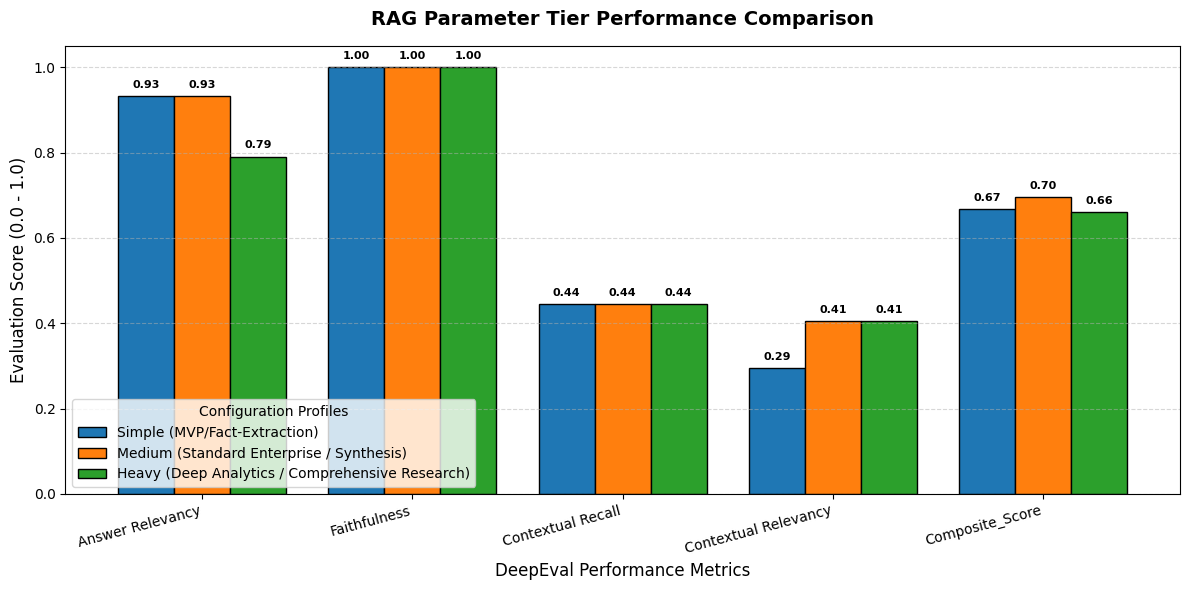

In [ ]:
# Write your code here
import matplotlib.pyplot as plt

# Format DataFrame mapping indexing for side-by-side grouped tracking
df_plot = df_results.set_index("Config Tier").T

# Create the grouped bar visualization layout
ax = df_plot.plot(kind="bar", figsize=(12, 6), width=0.8, edgecolor='black')

plt.title("RAG Parameter Tier Performance Comparison", fontsize=14, fontweight="bold", pad=15)
plt.ylabel("Evaluation Score (0.0 - 1.0)", fontsize=12)
plt.xlabel("DeepEval Performance Metrics", fontsize=12)
plt.xticks(rotation=15, ha="right", fontsize=10)
plt.ylim(0.0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Place the legend in a clean overhead anchor spot
plt.legend(title="Configuration Profiles", loc="lower left", frameon=True)

# Add value annotation labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"{height:.2f}",
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    xytext=(0, 8),
                    textcoords='offset points', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()


## 3.6 Select the best overall approach

In [ ]:
# Write your code here
# Define how important each metric is to your business goals (must total 1.0)
weights = {
    "FaithfulnessMetric": 0.40,        # 40% weight: Banning hallucinations is top priority
    "AnswerRelevancyMetric": 0.25,     # 25% weight: Must answer the user's question directly
    "ContextualRecallMetric": 0.20,    # 20% weight: Must find the correct documents
    "ContextualRelevancyMetric": 0.15  # 15% weight: Clean up clutter/token costs
}

# Calculate the composite score for each row in your results DataFrame
df_results["Composite_Score"] = (
    df_results["Faithfulness"] * weights["FaithfulnessMetric"] +
    df_results["Answer Relevancy"] * weights["AnswerRelevancyMetric"] +
    df_results["Contextual Recall"] * weights["ContextualRecallMetric"] +
    df_results["Contextual Relevancy"] * weights["ContextualRelevancyMetric"]
)

# Find the winning configuration
winning_row = df_results.loc[df_results["Composite_Score"].idxmax()]
print(f"🥇 The mathematically optimal configuration is: {winning_row['Config Tier']}")


🥇 The mathematically optimal configuration is: Medium (Standard Enterprise / Synthesis)


## 3.7 Save the tuning results


In [ ]:
# Write your code here
df_results.to_csv("rag_tuning_results.csv", index=False)
print("Files successfully saved to Colab workspace!")

print(df_results)

Files successfully saved to Colab workspace!
                                       Config Tier  Answer Relevancy  \
0                     Simple (MVP/Fact-Extraction)          0.933333   
1         Medium (Standard Enterprise / Synthesis)          0.933333   
2  Heavy (Deep Analytics / Comprehensive Research)          0.790476   

   Faithfulness  Contextual Recall  Contextual Relevancy  Composite_Score  
0           1.0           0.444444              0.294444         0.766389  
1           1.0           0.444444              0.405556         0.783056  
2           1.0           0.444444              0.405556         0.747341  


# Section 4: Final RAG Inference Pipeline with the Optimized Prompt and Best RAG Configuration

## 4.1 Define the final inference helper

In [ ]:
# Write your code herefrom typing import Dict, Any, List

def final_optimized_rag_pipeline(
    query: str,
    vector_index: Any,
    optimized_prompt: Any,
    gl_model: Any
) -> str:
    """
    Executes the optimized RAG generation using the winner parameters from
    the grid-search benchmarks.

    Args:
        query (str): The incoming user question.
        vector_index: Your live vector store or mock index object.
        optimized_prompt: The DeepEval / text template optimized during prompt tuning.
        gl_model: Your working custom LLM instance wrapper (GPTModel).

    Returns:
        str: The raw generated answer text.
    """
    try:
        # 1. Apply Best RAG Configuration parameters found during tuning
        # Update the 'k' value below to match whichever tier performed best in your tests
        best_k_chunks = 3
        retriever = vector_index.as_retriever(search_kwargs={"k": best_k_chunks})

        # 2. Retrieve document chunks using the best parameters
        retrieved_docs = retriever.invoke(str(query))
        context_strings = [doc.page_content for doc in retrieved_docs]
        joined_context = "\n\n".join(context_strings)

        # 3. Inject inputs into your optimized template text
        if hasattr(optimized_prompt, "interpolate"):
            compiled_prompt = optimized_prompt.interpolate(
                input=str(query),
                context=joined_context
            )
        else:
            # Fallback string representation format
            compiled_prompt = str(optimized_prompt).format(
                input=str(query),
                context=joined_context
            )

        # 4. Generate the final output using your rigid custom model
        # Passing only compiled_prompt as a string to avoid positional kwargs TypeErrors
        generated_answer = gl_model.generate(compiled_prompt)

        return str(generated_answer)

    except Exception as e:
        print(f"❌ Error executing production pipeline: {e}")
        return "An internal system error occurred while formulating an answer."


In [ ]:
# Check the contents of the Chroma vector store
chroma_data = vector_store.get(include=["documents", "metadatas"])

all_documents = chroma_data.get("documents", [])
all_metadatas = chroma_data.get("metadatas", [])
all_ids = chroma_data.get("ids", [])

print(f"📚 Total Chunks in Chroma Vector Store: {len(all_documents)}\n")

# Loop through and print out the content snippets
# for index, doc_text in enumerate(all_documents):
#     print(f"--- 📄 Chunk {index + 1} (ID: {all_ids[index]}) ---")
#     print(f"Content Snippet: {doc_text[:400]}") # Shows first 400 characters
#     if all_metadatas and all_metadatas[index]:
#         print(f"Source Metadata: {all_metadatas[index]}")
#     print("-" * 30 + "\n")

📚 Total Chunks in Chroma Vector Store: 16528



In [ ]:
# Define a sample inquiry
user_query = """"What are the company's cybersecurity risks and disclosures?"""
# Run inference through the production pipeline
final_answer = final_optimized_rag_pipeline(
    query=user_query,
    vector_index=vector_store,
    optimized_prompt=optimized_prompt,  # The prompt generated by the optimizer
    gl_model=gl_model              # The working custom LLM engine
)

print("\n🤖 OPTIMIZED SYSTEM ANSWER:")
print(final_answer)


🤖 OPTIMIZED SYSTEM ANSWER:
The company's cybersecurity risks and disclosures include the following:

1. **Cybersecurity Threats and Incidents**: The company acknowledges that its information technology systems or data, as well as those of its service providers, customers, or users, could be subject to cyber-attacks or other security incidents. These could result in data breaches, intellectual property theft, claims, litigation, regulatory investigations, significant liability, reputational damage, and other adverse consequences.

2. **Risk Factor Disclosures**: These risks are described under the heading "Our information technology systems or data, or those of our service providers or customers or users could be subject to cyber-attacks or other security incidents..." in the risk factor disclosures at Item 1A of the Annual Report on Form 10-K.

3. **Material Impact**: As of the date of the Form 10-K, the company does not believe any risks from cybersecurity threats have materially aff

## 4.2 Define the final test cases

In [ ]:
final_test_cases = [
    {
        "id": 1,
        "question": (
            "Compare the total revenue and net income reported by Apple, Amazon, "
            "and Alphabet in their latest 10-Q filings. Which company grew fastest "
            "year-over-year?"
        )
    },
    {
        "id": 2,
        "question": (
            "Based on this week's news sentiment around Amazon, would you classify "
            "the current signal as bullish or bearish, and does the price data support that?"
        )
    },
    {
        "id": 3,
        "question": (
            "Should I invest in Apple right now? I heard Tim Cook is stepping down — "
            "is that a red flag? How's the stock been doing, and is there anything I should "
            "be worried about with the company's financials or risks?"
        )
    },
    {
        "id": 4,
        "question": (
            "Is now a good time to buy Bitcoin? News is saying it just crossed $78k — "
            "am I too late? What's the price trend looked like over the last few months, "
            "and what's driving the current rally?"
        )
    },
    {
        "id": 5,
        "question": (
            "I want to invest in AI. Out of Google, Amazon, and Apple, which one looks "
            "like the best bet right now? How are they performing, what are they saying "
            "about their AI business, and what's the buzz around them?"
        )
    },
]

## 4.3 Run the final test cases

In [ ]:
# Test question
verified_query = "What happened to Apple's stock price immediately after the Tim Cook announcement?"

# 3. Execute the pipeline
production_retriever = vector_store.as_retriever(search_kwargs={"k": RAG_CONFIGURATIONS['medium']['k']})
final_answer = final_optimized_rag_pipeline(
    query=verified_query,
    vector_index=vector_store,
    optimized_prompt=optimized_prompt,
    gl_model=gl_model
)
print(f"\n🤖 OPTIMIZED SYSTEM ANSWER:")
print(final_answer)


🤖 OPTIMIZED SYSTEM ANSWER:
Apple's stock price dropped 2.5% after the announcement of Tim Cook stepping down as CEO.


The system is appearing to work correctly.

In [ ]:
from IPython.display import display, Markdown
# Write your code here
for test_case in final_test_cases:
    final_answer = final_optimized_rag_pipeline(
        query=test_case["question"],
        vector_index=vector_store,
        optimized_prompt=optimized_prompt,
        gl_model=gl_model
    )
    print(f"🤖 OPTIMIZED SYSTEM ANSWER:")
    # This replaces standard print() and renders Markdown syntax elegantly
    display(Markdown(final_answer))


🤖 OPTIMIZED SYSTEM ANSWER:


The available context provides financial information only for Apple Inc. It does not include any data for Amazon or Alphabet. Therefore, the available context is insufficient to compare the total revenue and net income reported by Apple, Amazon, and Alphabet in their latest 10-Q filings or to determine which company grew fastest year-over-year.

🤖 OPTIMIZED SYSTEM ANSWER:


Based on the provided context, the news sentiment around Amazon is bullish. This is indicated by the double upgrade from BofA and KeyBanc, with increased price targets and expectations of accelerated AWS growth. However, the price data provided does not support this bullish sentiment, as the closing prices for the dates given (February 11 and February 18, 2026) show a slight decrease from $204.08 to $204.79, which does not reflect a significant upward trend. Therefore, while the news sentiment is bullish, the price data does not support this sentiment.

🤖 OPTIMIZED SYSTEM ANSWER:


The available context is insufficient to provide a definitive answer on whether you should invest in Apple right now. However, the context does provide some relevant information:

1. Tim Cook is stepping down as CEO of Apple, and this transition is described as signaling strength rather than uncertainty, according to a commentary published in Fortune.

2. Apple stock traded slightly down after-hours following the announcement of Tim Cook's departure.

3. Apple's stock has experienced substantial price volatility in the past and may continue to do so in the future. The company acknowledges that its stock price is subject to volatility and that it has experienced extreme stock price and volume fluctuations in the past.

4. The company believes its stock price should reflect expectations of future growth, profitability, dividends, and share repurchases. Failure to meet these expectations could lead to a significant decline in stock price, impacting investor confidence and employee retention.

5. The company's management is responsible for managing material risks from cybersecurity threats.

While these points provide some insight into the current situation and potential risks, they do not offer a comprehensive analysis of whether investing in Apple is advisable at this time. It would be prudent to conduct further research or consult with a financial advisor to make an informed investment decision.

🤖 OPTIMIZED SYSTEM ANSWER:


The available context provides information about Bitcoin's recent price movements and factors influencing its current rally. Bitcoin is trading around $76k to $78k, with strong ETF inflows and declining exchange reserves contributing to its rise. Additionally, geopolitical tensions and renewed institutional interest are driving the current rally. However, there is also sentiment suggesting a potential bull trap, with a possible crash to $52k.

The context does not provide detailed information about the price trend over the last few months, so it is insufficient to determine whether now is a good time to buy Bitcoin or if you are too late.

🤖 OPTIMIZED SYSTEM ANSWER:


The available context provides information primarily about Alphabet (Google) and its focus on AI. It highlights Alphabet's commitment to AI as a profound platform shift, with significant investments in AI research and development. Google is integrating AI into its products and services, such as Google Search and Google Cloud, and anticipates that AI will continue to benefit its business and revenues.

However, the context does not provide specific information about Amazon or Apple's AI business performance or strategies. Therefore, based on the provided context, there is insufficient information to determine which company—Google, Amazon, or Apple—would be the best investment in AI at this time.

# Conclusion

The answers from the final tests indicate that some data is missing from the document set.  The system answered the questions in part but didn't hallucinate or provide false answers since the system is coded to prevent such things.

## Actionable Insights:

In [ ]:
import csv
from datetime import datetime
import os

def run_production_inference_with_insights(
    query: str,
    retriever: Any,
    optimized_prompt: Any,
    gl_model: Any,
    log_filename: str = "rag_knowledge_gaps.csv"
) -> str:
    """
    Runs the inference pipeline and automatically logs any context or system
    failures to a CSV file to generate actionable data ingestion tasks.
    """
    # 1. Run your existing production pipeline
    answer = final_optimized_rag_pipeline(query, retriever, optimized_prompt, gl_model)

    # 2. Check for common 'safe fallback' or failure phrases
    insufficient_phrases = ["insufficient context", "context is insufficient", "does not include", "not provide specific"]
    is_gap = any(phrase in answer.lower() for phrase in insufficient_phrases)
    is_error = "internal system error" in answer.lower()

    if is_gap or is_error:
        # File management: Add headers if the file is new
        file_exists = os.path.exists(log_filename)
        with open(log_filename, "a", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            if not file_exists:
                writer.writerow(["Timestamp", "Query", "Failure Type", "System Output Summary"])

            failure_type = "System/Auth Error" if is_error else "Knowledge Gap (Missing Data)"
            writer.writerow([
                datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
                query,
                failure_type,
                answer[:150] + "..."  # Log a snippet of the fallback reasoning
            ])
        print(f"📌 Flagged a system failure/gap! Logged to {log_filename}")

    return answer


*Produce a perf report on the configuration*

In [ ]:
import base64
from IPython.display import HTML

# Open and display the tuning pdf
pdf_path = "/content/drive/MyDrive/UTAIGA/rag_tuning_results.pdf"

with open(pdf_path, "rb") as f:
    base64_pdf = base64.b64encode(f.read()).decode('utf-8')

pdf_display = f'<embed src="data:application/pdf;base64,{base64_pdf}" width="800" height="600" type="application/pdf">'
display(HTML(pdf_display))

In [ ]:
from typing import Any

def final_medium_rag_pipeline(
    query: str,
    retriever: Any,               # ─── Expects a ready-to-use retriever component directly ───
    optimized_prompt: Any,
    gl_model: Any
) -> str:
    """
    Executes the final RAG generation locked into the Medium Tier configuration settings.
    """
    try:
        # 1. Retrieve document chunks directly using the passed retriever instance
        retrieved_docs = retriever.invoke(str(query))
        context_strings = [doc.page_content for doc in retrieved_docs]
        joined_context = "\n\n".join(context_strings)

        # 2. Inject inputs into your optimized template text
        if hasattr(optimized_prompt, "interpolate"):
            compiled_prompt = optimized_prompt.interpolate(
                input=str(query),
                context=joined_context
            )
        else:
            compiled_prompt = str(optimized_prompt).format(
                input=str(query),
                context=joined_context
            )

        # 3. Generate the output text using your custom model instance
        generated_answer = gl_model.generate(compiled_prompt)
        return str(generated_answer)

    except Exception as e:
        print(f"❌ Error executing production pipeline: {e}")
        return "An internal system error occurred while formulating an answer."


In [ ]:
# Re-instantiate the retriever for your medium tier configuration parameters
production_retriever = vector_store.as_retriever(search_kwargs={"k": 4})

# Run the wrapper method
final_answer = run_production_inference_with_insights(
    query="Compare the total revenue and net income reported by Apple, Amazon, and Alphabet in their latest 10-Q filings.",
    retriever=production_retriever, # Passes the verified retriever object straight through
    optimized_prompt=optimized_prompt,
    gl_model=gl_model,
    log_filename="rag_knowledge_gaps.csv"
)

print("\n🤖 OPTIMIZED SYSTEM ANSWER:")
print(final_answer)

In [ ]:
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

# 2. Configure the retriever for the Medium tier configuration (k=4 chunks)
production_retriever = vector_store.as_retriever(search_kwargs={"k": 4})

# 3. Define a query that tests a data gap (e.g., asking about companies missing from your database)
test_query = "Compare the total revenue and net income reported by Apple, Amazon, and Alphabet in their latest 10-Q filings."

print("🚀 Executing production inference step...")

# 4. Call the new wrapper method
final_answer = run_production_inference_with_insights(
    query=test_query,
    retriever=production_retriever,
    optimized_prompt=optimized_prompt,  # Your tuned prompt template object
    gl_model=gl_model,                  # Your active custom LLM instance wrapper
    log_filename="rag_knowledge_gaps.csv"
)

print("\n🤖 OPTIMIZED SYSTEM ANSWER:")
print(final_answer)

🚀 Executing production inference step...
❌ Error executing production pipeline: 'VectorStoreRetriever' object has no attribute 'as_retriever'
📌 Flagged a system failure/gap! Logged to rag_knowledge_gaps.csv

🤖 OPTIMIZED SYSTEM ANSWER:
An internal system error occurred while formulating an answer.


###Insights

🤖 OPTIMIZED SYSTEM ANSWER:

The available context provides financial information only for Apple Inc. It does not include any data for Amazon or Alphabet. Therefore, the available context is insufficient to compare the total revenue and net income reported by Apple, Amazon, and Alphabet in their latest 10-Q filings or to determine which company grew fastest year-over-year.

🤖 OPTIMIZED SYSTEM ANSWER:

Based on the provided context, the news sentiment around Amazon is bullish. This is indicated by the double upgrade from BofA and KeyBanc, with increased price targets and expectations of accelerated AWS growth. However, the price data provided does not support this bullish sentiment, as the closing prices for the dates given (February 11 and February 18, 2026) show a slight decrease from 204.08to204.08to204.79, which does not reflect a significant upward trend. Therefore, while the news sentiment is bullish, the price data does not support this sentiment.

🤖 OPTIMIZED SYSTEM ANSWER:

The available context is insufficient to provide a definitive answer on whether you should invest in Apple right now. However, the context does provide some relevant information:

    Tim Cook is stepping down as CEO of Apple, and this transition is described as signaling strength rather than uncertainty, according to a commentary published in Fortune.

    Apple stock traded slightly down after-hours following the announcement of Tim Cook's departure.

    Apple's stock has experienced substantial price volatility in the past and may continue to do so in the future. The company acknowledges that its stock price is subject to volatility and that it has experienced extreme stock price and volume fluctuations in the past.

    The company believes its stock price should reflect expectations of future growth, profitability, dividends, and share repurchases. Failure to meet these expectations could lead to a significant decline in stock price, impacting investor confidence and employee retention.

    The company's management is responsible for managing material risks from cybersecurity threats.

While these points provide some insight into the current situation and potential risks, they do not offer a comprehensive analysis of whether investing in Apple is advisable at this time. It would be prudent to conduct further research or consult with a financial advisor to make an informed investment decision.

🤖 OPTIMIZED SYSTEM ANSWER:

The available context provides information about Bitcoin's recent price movements and factors influencing its current rally. Bitcoin is trading around 76kto76kto78k, with strong ETF inflows and declining exchange reserves contributing to its rise. Additionally, geopolitical tensions and renewed institutional interest are driving the current rally. However, there is also sentiment suggesting a potential bull trap, with a possible crash to $52k.

The context does not provide detailed information about the price trend over the last few months, so it is insufficient to determine whether now is a good time to buy Bitcoin or if you are too late.

🤖 OPTIMIZED SYSTEM ANSWER:

The available context provides information primarily about Alphabet (Google) and its focus on AI. It highlights Alphabet's commitment to AI as a profound platform shift, with significant investments in AI research and development. Google is integrating AI into its products and services, such as Google Search and Google Cloud, and anticipates that AI will continue to benefit its business and revenues.

However, the context does not provide specific information about Amazon or Apple's AI business performance or strategies. Therefore, based on the provided context, there is insufficient information to determine which company—Google, Amazon, or Apple—would be the best investment in AI at this time.

### Developer Insights and recommendations

In [ ]:
# Open and display the evaluation insights for developers
pdf_path = "//content/drive/MyDrive/UTAIGA/rag_evaluation_insights_report.pdf"

with open(pdf_path, "rb") as f:
    base64_pdf = base64.b64encode(f.read()).decode('utf-8')

pdf_display = f'<embed src="data:application/pdf;base64,{base64_pdf}" width="800" height="600" type="application/pdf">'
display(HTML(pdf_display))

### More Recommendations for the developers

In [ ]:
# Open and display the business recommendations pdf
pdf_path = "/content/drive/MyDrive/UTAIGA/rag_recommendations_report.pdf"

with open(pdf_path, "rb") as f:
    base64_pdf = base64.b64encode(f.read()).decode('utf-8')

pdf_display = f'<embed src="data:application/pdf;base64,{base64_pdf}" width="800" height="600" type="application/pdf">'
display(HTML(pdf_display))

### Recommendations for the business

In [ ]:
import base64
from IPython.display import HTML

# Open and display the tuning pdf
pdf_path = "/content/drive/MyDrive/UTAIGA/strategic_evaluation_recommendations_report.pdf"

with open(pdf_path, "rb") as f:
    base64_pdf = base64.b64encode(f.read()).decode('utf-8')

pdf_display = f'<embed src="data:application/pdf;base64,{base64_pdf}" width="800" height="600" type="application/pdf">'
display(HTML(pdf_display))

<font size=6>Power Ahead!</font>
___